# Granger-causality analysis

run this notebook in the gc_dvg environment

**Table of Contents**
- [Granger-causality analysis](#Granger-causality-analysis)
- [Data Preparation](#Data-Preparation)
  - [import the data set](#import-the-data-set)
    - [read count data](#read-count-data)
    - [cultivation data](#cultivation-data)
  - [Log-normalization](#Log-normalization)
  - [Stationarity](#Stationarity)
    - [iterative method](#iterative-method)
- [Granger-causality test](#Granger-causality-test)
  - [Make Granger-causality matrix](#Make-Granger-causality-matrix)
  - [Summarize](#Summarize)
- [Plot fitted models](#Plot-fitted-models)
  - [Functions](#Functions)
    - [Performance metrics](#Performance-metrics)
    - [Plot single fits](#Plot-single-fits)
  - [Fitting and plotting](#Fitting-and-plotting)
    - [all](#all)
    - [corrected](#corrected)
  - [plot single candidates](#plot-single-candidates)
  - [Plot all candidates of a group](#Plot-all-candidates-of-a-group)
- [Swarmplots](#Swarmplots)
  - [Helper Functions](#Helper-Functions)
  - [Functions](#Functions)
  - [all](#all)
  - [corrected](#corrected)
- [group sizes with increasing lag](#group-sizes-with-increasing-lag)
  - [all](#all)
  - [corrected](#corrected)
  - [all vs corrected](#all-vs-corrected)
- [SSR with increasing lag](#SSR-with-increasing-lag)
  - [corrected](#corrected)
- [Granger causality test only on non-zero parts of the time series for PB2_269_2202](#Granger-causality-test-only-on-non-zero-parts-of-the-time-series-for-PB2_269_2202)
- [Granger causality test only on non-zero parts of the time series for PB2_129_2176](#Granger-causality-test-only-on-non-zero-parts-of-the-time-series-for-PB2_129_2176)

First import all necessary packages for Granger-causality analysis & forecasting

In [1]:
from utils.dip_utils import *
from utils.dip_visuals import *

import matplotlib.pyplot as plt
import pelz_datasets
import numpy as np

from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings('ignore')

pickling time2id dictionaries


In [2]:
import json, re

with open('01_granger_causality_analysis_dvg_classification.ipynb') as f:
    nb = json.load(f)

toc = []
for cell in nb['cells']:
    if cell['cell_type'] != 'markdown':
        continue
    for line in cell['source']:
        m = re.match(r'^(#{1,6})\s+(.*)', line)
        if m:
            level = len(m.group(1))
            title = m.group(2).strip()
            anchor = re.sub(r'[^\w\- ]', '', title).strip().replace(' ', '-')
            toc.append(f"{'  ' * (level-1)}- [{title}](#{anchor})")

# print('\n'.join(toc))

In [3]:
import json, re
from IPython.display import Markdown

with open('01_granger_causality_analysis_dvg_classification.ipynb') as f:
    nb = json.load(f)

toc = []
for cell in nb['cells']:
    if cell['cell_type'] != 'markdown':
        continue
    for line in cell['source']:
        m = re.match(r'^(#{1,6})\s+(.*)', line)
        if m:
            level = len(m.group(1))
            title = m.group(2).strip()
            anchor = re.sub(r'[^\w\- ]', '', title).strip().replace(' ', '-')
            toc.append(f"{'  ' * (level-1)}- [{title}](#{anchor})")

Markdown('\n'.join(toc))

- [Granger-causality analysis](#Granger-causality-analysis)
- [Data Preparation](#Data-Preparation)
  - [import the data set](#import-the-data-set)
    - [read count data](#read-count-data)
    - [cultivation data](#cultivation-data)
  - [Log-normalization](#Log-normalization)
  - [Stationarity](#Stationarity)
    - [iterative method](#iterative-method)
- [Granger-causality test](#Granger-causality-test)
  - [Make Granger-causality matrix](#Make-Granger-causality-matrix)
  - [Summarize](#Summarize)
- [Plot fitted models](#Plot-fitted-models)
  - [Functions](#Functions)
    - [Performance metrics](#Performance-metrics)
    - [Plot single fits](#Plot-single-fits)
  - [Fitting and plotting](#Fitting-and-plotting)
    - [all](#all)
    - [corrected](#corrected)
  - [plot single candidates](#plot-single-candidates)
  - [Plot all candidates of a group](#Plot-all-candidates-of-a-group)
- [Swarmplots](#Swarmplots)
  - [Helper Functions](#Helper-Functions)
  - [Functions](#Functions)
  - [all](#all)
  - [corrected](#corrected)
- [group sizes with increasing lag](#group-sizes-with-increasing-lag)
  - [all](#all)
  - [corrected](#corrected)
  - [all vs corrected](#all-vs-corrected)
- [SSR with increasing lag](#SSR-with-increasing-lag)
  - [corrected](#corrected)
- [Granger causality test only on non-zero parts of the time series for PB2_269_2202](#Granger-causality-test-only-on-non-zero-parts-of-the-time-series-for-PB2_269_2202)
- [Granger causality test only on non-zero parts of the time series for PB2_129_2176](#Granger-causality-test-only-on-non-zero-parts-of-the-time-series-for-PB2_129_2176)

In [4]:
plt.rcParams['font.size'] = 20
plt.rcParams['font.family'] = 'Arial'

# Data Preparation

## import the data set

### read count data

In [5]:
long_pelz_readcounts_abs = pelz_datasets.long_readcounts(cutoff=15)
long_pelz_readcounts_abs = long_pelz_readcounts_abs.dropna()

measure_ids = long_pelz_readcounts_abs.columns[4:]
long_pelz_readcounts_abs


,key,segment,start,end,PN6,PN7,PN8,PN9,PN13,PN14,...,PN32,PN33,PN38,PN40,PN41,PN42,PN45,PN46,PN47,PN48
100,HA_123_1491,HA,123,1491,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,4.0,49.0,51.0,108.0,33.0,72.0,9.0
132,HA_126_1560,HA,126,1560,0.0,3.0,0.0,0.0,0.0,20.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
434,HA_189_1532,HA,189,1532,4.0,28.0,21.0,44.0,14.0,21.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
517,HA_208_1534,HA,208,1534,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.0,10.0,4.0,0.0,4.0,56.0,8.0,32.0,0.0
808,HA_47_107,HA,47,107,0.0,7.0,1.0,0.0,0.0,0.0,...,0.0,3.0,6.0,2.0,0.0,2.0,27.0,9.0,18.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32415,PB2_961_2065,PB2,961,2065,0.0,0.0,3.0,7.0,4.0,1.0,...,2.0,15.0,2.0,16.0,2.0,4.0,4.0,4.0,5.0,2.0
32431,PB2_97_122,PB2,97,122,0.0,3.0,13.0,16.0,24.0,32.0,...,0.0,15.0,2.0,5.0,0.0,0.0,0.0,0.0,0.0,1.0
32447,PB2_97_1975,PB2,97,1975,0.0,1.0,2.0,4.0,2.0,4.0,...,3.0,17.0,4.0,5.0,0.0,0.0,4.0,2.0,0.0,0.0
32480,PB2_98_130,PB2,98,130,0.0,8.0,10.0,11.0,16.0,6.0,...,7.0,10.0,2.0,1.0,0.0,3.0,5.0,7.0,1.0,1.0


### cultivation data
Not all values in our data set had sequenced samples so we need to match the measured values with the sequenced values through their time-points

In [6]:
cultivation_values = pelz_datasets.pelz_cultivation_values()
cultivation_values.drop(columns=['key', 'unit'], inplace=True)
cultivation_values
tp2dpi = cultivation_values.T['dpi'].apply(lambda d : round(d,2)).to_dict()

In [7]:
read_counts_T = long_pelz_readcounts_abs.copy()
read_counts_T.index = read_counts_T.key
read_counts_T = read_counts_T[long_pelz_readcounts_abs.columns[4:]].T
read_counts_T.index = [round(tp2dpi[idx], 2) for idx in read_counts_T.index]
read_counts_T


key,HA_123_1491,HA_126_1560,HA_189_1532,HA_208_1534,HA_47_107,HA_93_1460,M_126_741,M_132_939,M_175_907,NA_175_1066,...,PB2_91_123,PB2_91_2004,PB2_922_2211,PB2_92_116,PB2_94_122,PB2_961_2065,PB2_97_122,PB2_97_1975,PB2_98_130,PB2_98_2005
-0.02,0.0,0.0,4.0,0.0,0.0,0.0,5.0,37.0,0.0,35.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.50,0.0,3.0,28.0,0.0,7.0,0.0,0.0,1.0,0.0,21.0,...,15.0,5.0,0.0,2.0,5.0,0.0,3.0,1.0,8.0,0.0
0.99,0.0,0.0,21.0,0.0,1.0,0.0,3.0,10.0,6.0,3.0,...,22.0,8.0,1.0,9.0,0.0,3.0,13.0,2.0,10.0,0.0
1.40,0.0,0.0,44.0,0.0,0.0,0.0,5.0,3.0,0.0,11.0,...,24.0,11.0,0.0,7.0,2.0,7.0,16.0,4.0,11.0,0.0
3.46,0.0,0.0,14.0,0.0,0.0,0.0,2.0,3.0,0.0,5.0,...,14.0,10.0,3.0,0.0,4.0,4.0,24.0,2.0,16.0,0.0
4.00,0.0,20.0,21.0,0.0,0.0,0.0,0.0,2.0,0.0,3.0,...,20.0,13.0,0.0,5.0,9.0,1.0,32.0,4.0,6.0,0.0
4.47,0.0,0.0,25.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,...,7.0,10.0,1.0,0.0,13.0,2.0,19.0,2.0,9.0,0.0
5.00,0.0,0.0,6.0,0.0,0.0,0.0,1.0,3.0,0.0,3.0,...,73.0,47.0,7.0,19.0,25.0,8.0,19.0,19.0,17.0,23.0
5.48,0.0,0.0,1.0,0.0,0.0,0.0,2.0,15.0,0.0,9.0,...,55.0,25.0,8.0,15.0,12.0,2.0,10.0,9.0,26.0,10.0
7.95,0.0,0.0,5.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,...,23.0,20.0,11.0,19.0,4.0,6.0,24.0,10.0,11.0,7.0


In [8]:
cult_df = cultivation_values.T[['dpi', 'plaque_assay']]
cult_df.index = [round(d,2) for d in cult_df.dpi]
cult_df = cult_df.drop(columns=['dpi'])
cult_df


,plaque_assay
-0.02,280000
0.50,280000000
0.99,28000000
1.40,4000000
2.02,120000
2.49,12000
2.95,600
3.46,120
4.00,4
4.47,4000


In [9]:
ts_df = pd.merge(left=cult_df,
              right=read_counts_T,
              left_index=True,
              right_index=True,
              how='left')
ts_df['plaque_assay'] = pd.to_numeric(ts_df['plaque_assay'], errors='coerce')
ts_df

,plaque_assay,HA_123_1491,HA_126_1560,HA_189_1532,HA_208_1534,HA_47_107,HA_93_1460,M_126_741,M_132_939,M_175_907,...,PB2_91_123,PB2_91_2004,PB2_922_2211,PB2_92_116,PB2_94_122,PB2_961_2065,PB2_97_122,PB2_97_1975,PB2_98_130,PB2_98_2005
-0.02,280000.0,0.0,0.0,4.0,0.0,0.0,0.0,5.0,37.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.50,280000000.0,0.0,3.0,28.0,0.0,7.0,0.0,0.0,1.0,0.0,...,15.0,5.0,0.0,2.0,5.0,0.0,3.0,1.0,8.0,0.0
0.99,28000000.0,0.0,0.0,21.0,0.0,1.0,0.0,3.0,10.0,6.0,...,22.0,8.0,1.0,9.0,0.0,3.0,13.0,2.0,10.0,0.0
1.40,4000000.0,0.0,0.0,44.0,0.0,0.0,0.0,5.0,3.0,0.0,...,24.0,11.0,0.0,7.0,2.0,7.0,16.0,4.0,11.0,0.0
2.02,120000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2.49,12000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2.95,600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3.46,120.0,0.0,0.0,14.0,0.0,0.0,0.0,2.0,3.0,0.0,...,14.0,10.0,3.0,0.0,4.0,4.0,24.0,2.0,16.0,0.0
4.00,4.0,0.0,20.0,21.0,0.0,0.0,0.0,0.0,2.0,0.0,...,20.0,13.0,0.0,5.0,9.0,1.0,32.0,4.0,6.0,0.0
4.47,4000.0,0.0,0.0,25.0,0.0,0.0,0.0,0.0,1.0,0.0,...,7.0,10.0,1.0,0.0,13.0,2.0,19.0,2.0,9.0,0.0


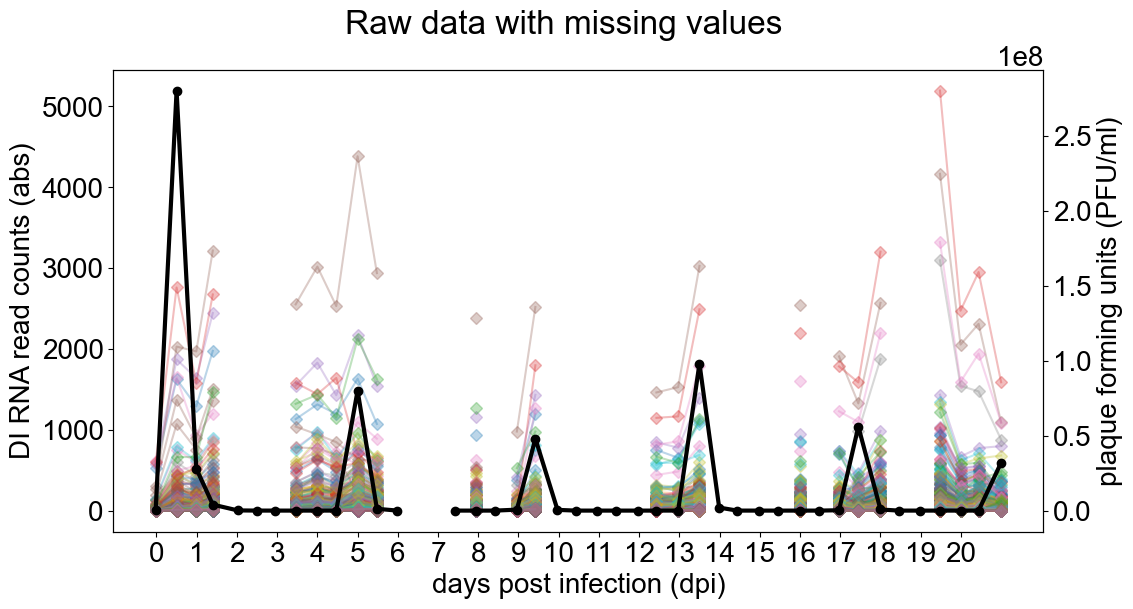

In [10]:
fig, ax = plt.subplots(figsize=(12,6))
ax2 = ax.twinx()
ax.set_xlabel('days post infection (dpi)')
ax.plot(ts_df.index,ts_df.drop(columns=['plaque_assay']),
          alpha=0.3, 
          marker='D'
          )
ax.set_ylabel('DI RNA read counts (abs)')
ax2.plot(ts_df.index, ts_df['plaque_assay'], 
        color='black', 
        marker='o', 
        label='PFU/ml',
        linewidth=3
        )
ax2.set_ylabel('plaque forming units (PFU/ml)')
ax2.set_xticks([range(0, max(ts_df.index.astype(int))+1)[i] for i in range(0, max(ts_df.index.astype(int)), 1)])
fig.suptitle('Raw data with missing values')
plt.show()


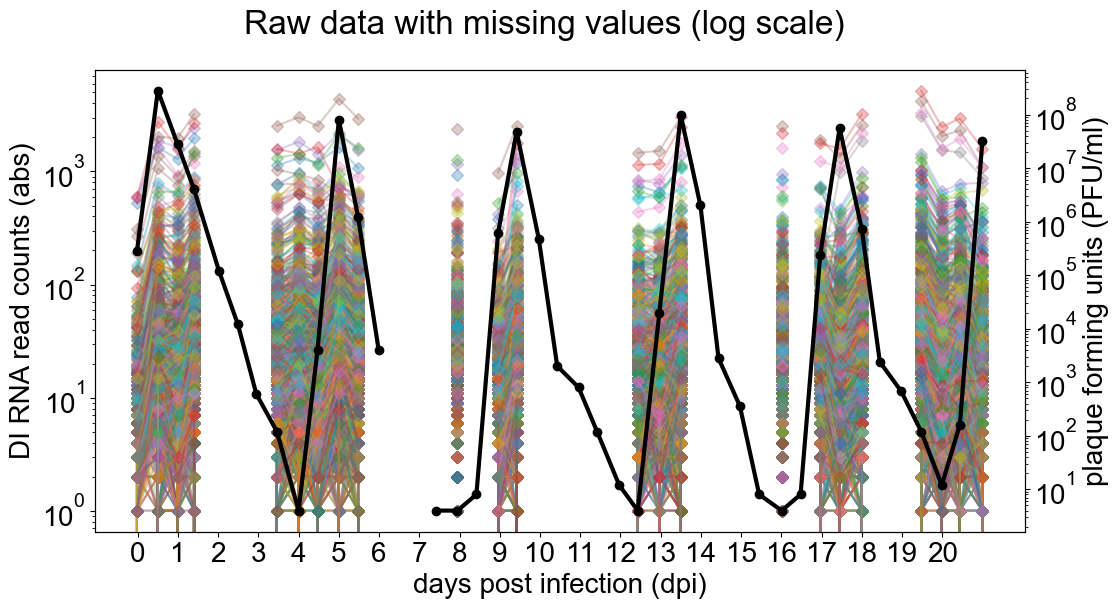

In [11]:
fig, ax = plt.subplots(figsize=(12,6))
ax2 = ax.twinx()
ax.set_xlabel('days post infection (dpi)')
ax.plot(ts_df.index,ts_df.drop(columns=['plaque_assay']),
          alpha=0.3, 
          marker='D'
          )
ax.set_ylabel('DI RNA read counts (abs)')
ax.set_yscale('log')
ax2.plot(ts_df.index, ts_df['plaque_assay'], 
        color='black', 
        marker='o', 
        label='PFU/ml',
        linewidth=3
        )
ax2.set_ylabel('plaque forming units (PFU/ml)')
ax2.set_yscale('log')
ax2.set_xticks([range(0, max(ts_df.index.astype(int))+1)[i] for i in range(0, max(ts_df.index.astype(int)), 1)])
fig.suptitle('Raw data with missing values (log scale)')
plt.show()

In [12]:
plaque_assay_missing_timepoints = ts_df[ts_df['plaque_assay'].isna()].index.tolist()
read_counts_missing_timepoints = ts_df[ts_df.drop(columns=['plaque_assay']).isna().any(axis=1)].index.tolist()
print(plaque_assay_missing_timepoints, read_counts_missing_timepoints)

[6.49, 6.96] [2.02, 2.49, 2.95, 5.99, 6.49, 6.96, 7.42, 8.42, 9.97, 10.43, 10.96, 11.42, 11.97, 13.99, 14.44, 14.97, 15.45, 16.48, 18.45, 18.98]


In [13]:
! mkdir -p data/outputs/plus1_log10_linear_imputation

lin_interpolated_ts_df = ts_df.copy()
lin_interpolated_ts_df['plaque_assay'] = lin_interpolated_ts_df['plaque_assay'].interpolate(method='linear')
lin_interpolated_ts_df = lin_interpolated_ts_df.interpolate(method='linear')
lin_interpolated_ts_df.to_csv('data/outputs/plus1_log10_linear_imputation/lin_interpolated_ts_df.csv')

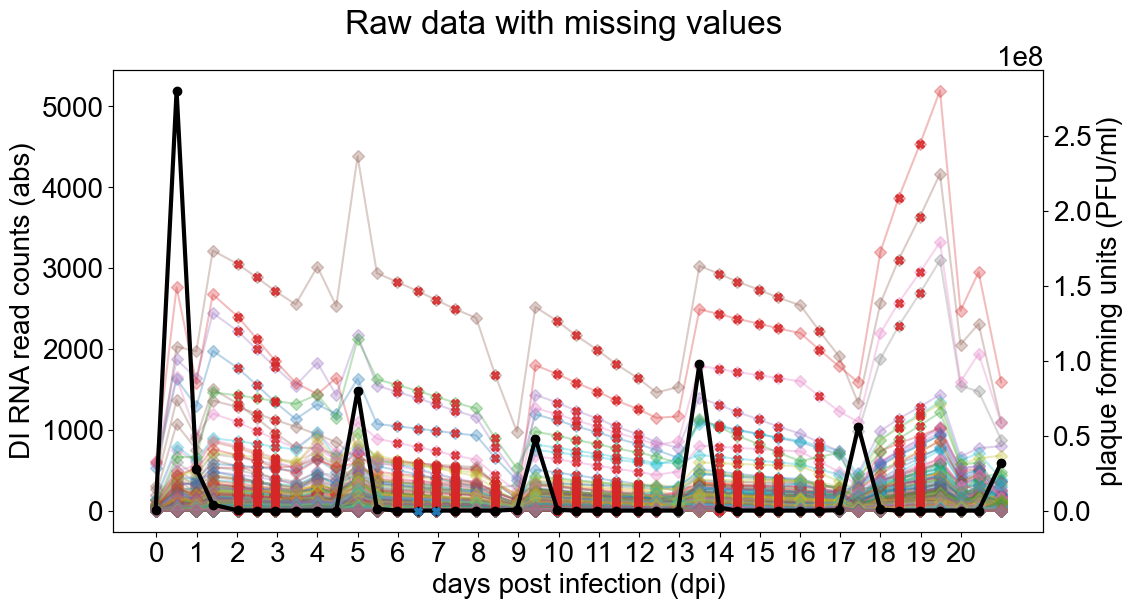

In [14]:
fig, ax = plt.subplots(figsize=(12,6))
ax2 = ax.twinx()
ax.set_xlabel('days post infection (dpi)')
ax.plot(lin_interpolated_ts_df.index,lin_interpolated_ts_df.drop(columns=['plaque_assay']),
          alpha=0.3, 
          marker='D'
          )
ax.plot(read_counts_missing_timepoints, lin_interpolated_ts_df.loc[read_counts_missing_timepoints].drop(columns=['plaque_assay']),
          alpha=0.8, 
          marker='X',
          color='tab:red',
          linewidth=0
          )
ax.set_ylabel('DI RNA read counts (abs)')
ax2.plot(lin_interpolated_ts_df.index, lin_interpolated_ts_df['plaque_assay'], 
        color='black', 
        marker='o', 
        label='PFU/ml',
        linewidth=3
        )
ax2.plot(plaque_assay_missing_timepoints, 
        lin_interpolated_ts_df.loc[plaque_assay_missing_timepoints]['plaque_assay'],
        marker='X',
        color='tab:blue',
        linewidth=0,
        zorder=10
        )
ax2.set_ylabel('plaque forming units (PFU/ml)')
ax2.set_xticks([range(0, max(lin_interpolated_ts_df.index.astype(int))+1)[i] for i in range(0, max(lin_interpolated_ts_df.index.astype(int)), 1)])
fig.suptitle('Raw data with missing values')
plt.show()


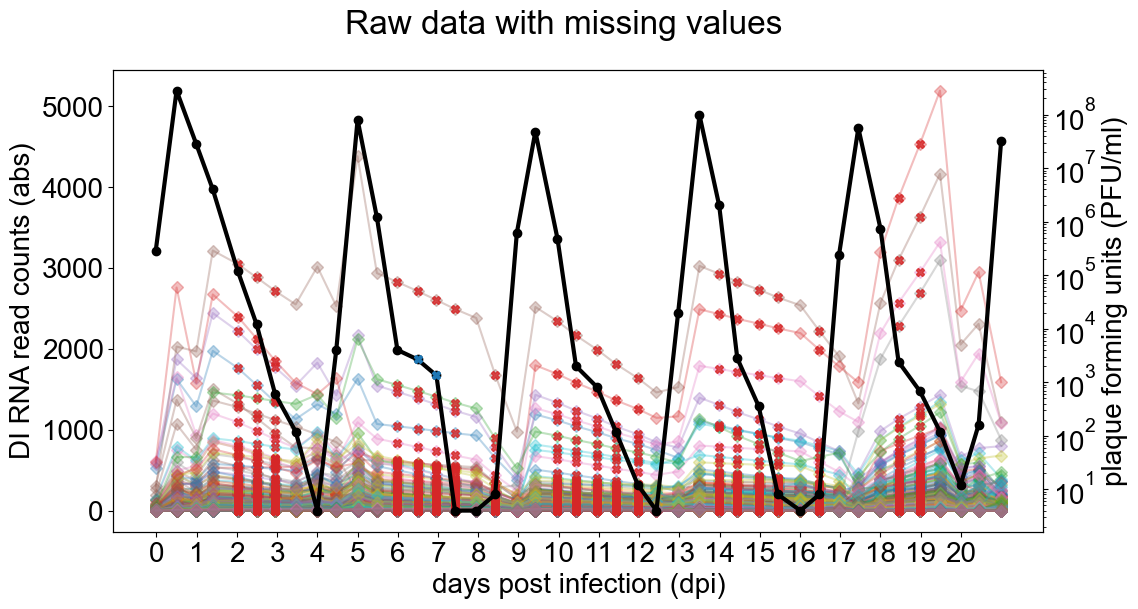

In [15]:
fig, ax = plt.subplots(figsize=(12,6))
ax2 = ax.twinx()
ax.set_xlabel('days post infection (dpi)')
ax.plot(lin_interpolated_ts_df.index,lin_interpolated_ts_df.drop(columns=['plaque_assay']),
          alpha=0.3, 
          marker='D'
          )
ax.plot(read_counts_missing_timepoints, lin_interpolated_ts_df.loc[read_counts_missing_timepoints].drop(columns=['plaque_assay']),
          alpha=0.8, 
          marker='X',
          color='tab:red',
          linewidth=0
          )
ax.set_ylabel('DI RNA read counts (abs)')
ax2.plot(lin_interpolated_ts_df.index, lin_interpolated_ts_df['plaque_assay'], 
        color='black', 
        marker='o', 
        label='PFU/ml',
        linewidth=3
        )
ax2.plot(plaque_assay_missing_timepoints, 
        lin_interpolated_ts_df.loc[plaque_assay_missing_timepoints]['plaque_assay'],
        marker='X',
        color='tab:blue',
        linewidth=0,
        zorder=10
        )
ax2.set_yscale('log')
ax2.set_ylabel('plaque forming units (PFU/ml)')
ax2.set_xticks([range(0, max(lin_interpolated_ts_df.index.astype(int))+1)[i] for i in range(0, max(lin_interpolated_ts_df.index.astype(int)), 1)])
fig.suptitle('Raw data with missing values')
plt.show()


## Log-normalization
To get our data on a easier to handle scale, we perform log transformation on the NGS-readcounts and the cultivation values: plaque_assay, tcid50, ha_titer and vrna

In [16]:
log_interpolated_ts_df = lin_interpolated_ts_df.applymap(lambda x: np.log10(x+1))
log_interpolated_ts_df

,plaque_assay,HA_123_1491,HA_126_1560,HA_189_1532,HA_208_1534,HA_47_107,HA_93_1460,M_126_741,M_132_939,M_175_907,...,PB2_91_123,PB2_91_2004,PB2_922_2211,PB2_92_116,PB2_94_122,PB2_961_2065,PB2_97_122,PB2_97_1975,PB2_98_130,PB2_98_2005
-0.02,5.447160,0.000000,0.000000,0.698970,0.000000,0.000000,0.000000,0.778151,1.579784,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.50,8.447158,0.000000,0.602060,1.462398,0.000000,0.903090,0.000000,0.000000,0.301030,0.000000,...,1.204120,0.778151,0.000000,0.477121,0.778151,0.000000,0.602060,0.301030,0.954243,0.000000
0.99,7.447158,0.000000,0.000000,1.342423,0.000000,0.301030,0.000000,0.602060,1.041393,0.845098,...,1.361728,0.954243,0.301030,1.000000,0.000000,0.602060,1.146128,0.477121,1.041393,0.000000
1.40,6.602060,0.000000,0.000000,1.653213,0.000000,0.000000,0.000000,0.778151,0.602060,0.000000,...,1.397940,1.079181,0.000000,0.903090,0.477121,0.903090,1.230449,0.698970,1.079181,0.000000
2.02,5.079185,0.000000,0.000000,1.574031,0.000000,0.000000,0.000000,0.720159,0.602060,0.000000,...,1.352183,1.070038,0.243038,0.795880,0.544068,0.860338,1.278754,0.653213,1.122216,0.000000
2.49,4.079217,0.000000,0.000000,1.477121,0.000000,0.000000,0.000000,0.653213,0.602060,0.000000,...,1.301030,1.060698,0.397940,0.653213,0.602060,0.812913,1.322219,0.602060,1.161368,0.000000
2.95,2.778874,0.000000,0.000000,1.352183,0.000000,0.000000,0.000000,0.574031,0.602060,0.000000,...,1.243038,1.051153,0.511883,0.439333,0.653213,0.759668,1.361728,0.544068,1.197281,0.000000
3.46,2.082785,0.000000,0.000000,1.176091,0.000000,0.000000,0.000000,0.477121,0.602060,0.000000,...,1.176091,1.041393,0.602060,0.000000,0.698970,0.698970,1.397940,0.477121,1.230449,0.000000
4.00,0.698970,0.000000,1.322219,1.342423,0.000000,0.000000,0.000000,0.000000,0.477121,0.000000,...,1.322219,1.146128,0.000000,0.778151,1.000000,0.301030,1.518514,0.698970,0.845098,0.000000
4.47,3.602169,0.000000,0.000000,1.414973,0.000000,0.000000,0.000000,0.000000,0.301030,0.000000,...,0.903090,1.041393,0.301030,0.000000,1.146128,0.477121,1.301030,0.477121,1.000000,0.000000


## Stationarity

Time-series analysis relies on stationarity so that the models and predictions can be statistically relevant and to avoid the detection of spurious relationships.
Thus we need to pre process the imported raw data. I used two methods to obtain stationarity:
1. The iterative method
-> repeatedly form the difference of one value at index i with its preceeding value i-1 in the input array

2. The direct method 
-> directly determine which increment is needed to get a stationary time-series (determine x if np.diff(x) gives us a stationary dataframe)

### iterative method

In [17]:
def make_stationary(input_df, timepoint_idx=4, max_diff=10,
                    autolag=None, max_lag=None):
    """transform the input_df to a stationary time series by iterative differencing

    Args:
        input_df (pandas dataframe): input dataframe
        timepoint_idx (int, optional): index of the column where the time points start in the input_dataframe. Defaults to 4.
        max_diff (int, optional): maximum differencing level. How many times differencing should be done if no stationarity is reached yet.
                                    Defaults to 10.

    Returns:
        _type_: _description_
    """
    df = input_df.copy()
    list_stationary = []
    list_nonstationary = []
    diff_levels = []
    diff_nonstationary_list = []
    lags = []
    timepoint_columns = df.columns[timepoint_idx:]
    
    if max_lag is None:
        max_lag = int(np.sqrt(len(timepoint_columns)))
        
    if autolag is None:
        autolag = 'AIC'
        
    for i, row in df.iterrows():
        diff_level = 0
        p_value = 100
        ts_data = row[timepoint_columns]
        last_data = ts_data.copy()
        # Apply first differencing
        
        # Perform adfuller test
        try:
            with np.errstate(divide='ignore'):
                adf_result = adfuller(ts_data, 
                                    autolag=autolag,
                                    regression='ct', 
                                    maxlag=max_lag)
        except:
            list_nonstationary.append(row)
            continue
        p_value = adf_result[1]
        
        if p_value <= 0.05:
            # If the time series is stationary, add it to the stationary list
            row[ts_data.index] = ts_data.values
            list_stationary.append(row)
            lags.append(adf_result[2])
            diff_levels.append(diff_level)
        else:
            while diff_level < max_diff:
                diff_data = last_data.diff().dropna()
                diff_level += 1
                with np.errstate(divide='ignore'):
                    adf_result = adfuller(diff_data, autolag=autolag, maxlag=max_lag)
                p_value = adf_result[1]
                if p_value <= 0.05:
                    row[diff_data.index] = diff_data.values
                    list_stationary.append(row)
                    lags.append(adf_result[2])
                    diff_levels.append(diff_level)
                    break
                elif diff_level == max_diff:
                    list_nonstationary.append(row)
                    diff_nonstationary_list.append(diff_data)
                last_data = diff_data.copy()
        
        
    if len(list_stationary) > 0:
        df_stationary = pd.concat(list_stationary, axis=1).T
    else:
        df_stationary = pd.DataFrame()
    if len(list_nonstationary) > 0:
        df_nonstationary = pd.concat(list_nonstationary, axis=1).T
    else:
        df_nonstationary = pd.DataFrame()
    if len(diff_nonstationary_list) > 0:
        df_diff_nonstationary = pd.concat(diff_nonstationary_list, axis=1).T
    else:
        df_diff_nonstationary = pd.DataFrame()
    return df_stationary, df_nonstationary,df_diff_nonstationary, diff_levels, lags

import types

def make_stationary(input_df, max_diff=10, autolag=None, max_lag=None, regression="c"):
    """Transform each column (candidate) to a stationary series by iterative differencing.

    Args:
        input_df (pd.DataFrame): rows are timepoints; columns are candidates/variables.
        max_diff (int): maximum differencing level. Defaults to 10.
        autolag (str | None): lag selection for ADF. Defaults to 'AIC'.
        max_lag (int | None): max lags for ADF. Defaults to sqrt(n_timepoints), then clamped.
        regression (str): ADF regression trend ('c', 'ct', 'ctt', 'nc'). Defaults to 'c'.

    Returns:
        df_stationary (pd.DataFrame): final stationary series (may be differenced) for stationary columns.
        df_nonstationary (pd.DataFrame): original non-stationary columns.
        df_diff_nonstationary (pd.DataFrame): last differenced data for non-stationary columns (np.diff, padded).
        diff_levels (pd.Series): differencing level used per column (NaN for non-stationary/error).
        lags (pd.Series): ADF-selected lag per column (NaN for non-stationary/error).
        pvals (pd.Series): final ADF p-value per column (NaN on error).
        status (pd.Series): "stationary", "non-stationary", or "error".
    """
    df = input_df.copy()
    n_timepoints = len(df)

    if autolag is None:
        autolag = "AIC"
    if max_lag is None:
        max_lag = int(np.sqrt(max(n_timepoints, 1)))
    # Clamp to feasible range
    max_lag = max(1, min(max_lag, max(1, n_timepoints // 2 - 1)))

    stationary_data = {}
    nonstationary_cols = []
    diff_nonstationary_dict = {}
    diff_levels = {}
    lags = {}
    pvals = {}
    status = {}

    for col in df.columns:
        series = pd.to_numeric(df[col], errors="coerce")
        # Drop NaNs for testing but keep original index for reconstruction
        ts_data = series.dropna().to_numpy()
        if len(ts_data) < 3 or len(ts_data) <= max_lag:
            # Too short for ADF with this max_lag
            nonstationary_cols.append(col)
            diff_nonstationary_dict[col] = np.diff(series.to_numpy()) if len(series) > 1 else np.array([])
            diff_levels[col] = np.nan
            lags[col] = np.nan
            pvals[col] = np.nan
            status[col] = "error"
            continue

        diff_level = 0
        last_data = ts_data.copy()

        def run_adf(arr):
            with np.errstate(divide='ignore', invalid='ignore'):
                return adfuller(arr, autolag=autolag, regression=regression, maxlag=max_lag)

        # Initial ADF
        try:
            adf_result = run_adf(last_data)
            p_value = adf_result[1]
        except Exception:
            nonstationary_cols.append(col)
            diff_nonstationary_dict[col] = np.diff(series.to_numpy()) if len(series) > 1 else np.array([])
            diff_levels[col] = np.nan
            lags[col] = np.nan
            pvals[col] = np.nan
            status[col] = "error"
            continue

        if p_value <= 0.05:
            # Already stationary; keep original cleaned series, realign to original index
            stationary_series = series
            stationary_data[col] = stationary_series
            diff_levels[col] = diff_level
            lags[col] = adf_result[2]
            pvals[col] = p_value
            status[col] = "stationary"
            continue

        # Iterative differencing
        became_stationary = False
        while diff_level < max_diff:
            diff_data = np.diff(last_data)
            diff_level += 1
            # Need at least 3 points to run ADF reasonably
            if len(diff_data) < 3 or len(diff_data) <= max_lag:
                # Can't test further; mark non-stationary
                break
            try:
                adf_result = run_adf(diff_data)
                p_value = adf_result[1]
            except Exception:
                break

            if p_value <= 0.05:
                # Store differenced series aligned to original index (pad front with NaN)
                padded = np.concatenate(([np.nan] * diff_level, diff_data))
                # Trim/pad to original length
                padded = padded[:n_timepoints] if len(padded) >= n_timepoints else np.pad(
                    padded, (0, n_timepoints - len(padded)), constant_values=np.nan
                )
                stationary_series = pd.Series(padded, index=df.index)
                stationary_data[col] = stationary_series
                diff_levels[col] = diff_level
                lags[col] = adf_result[2]
                pvals[col] = p_value
                status[col] = "stationary"
                became_stationary = True
                break

            last_data = diff_data

        if not became_stationary:
            nonstationary_cols.append(col)
            # Keep the last differenced data for inspection
            diff_nonstationary_dict[col] = np.diff(series.to_numpy()) if len(series) > 1 else np.array([])
            diff_levels[col] = np.nan
            lags[col] = np.nan
            pvals[col] = np.nan
            status[col] = "non-stationary"

    # Assemble outputs
    df_stationary = pd.DataFrame(stationary_data, index=df.index) if stationary_data else pd.DataFrame(index=df.index)
    df_nonstationary = df[nonstationary_cols].copy() if nonstationary_cols else pd.DataFrame(index=df.index)

    if diff_nonstationary_dict:
        padded = {}
        for col, arr in diff_nonstationary_dict.items():
            # np.diff gives length n-1; pad with leading NaN to align to n
            padded_arr = np.concatenate(([np.nan], arr))
            if len(padded_arr) < n_timepoints:
                padded_arr = np.pad(padded_arr, (0, n_timepoints - len(padded_arr)), constant_values=np.nan)
            else:
                padded_arr = padded_arr[:n_timepoints]
            padded[col] = padded_arr
        df_diff_nonstationary = pd.DataFrame(padded, index=df.index)
    else:
        df_diff_nonstationary = pd.DataFrame(index=df.index)

    return types.SimpleNamespace(
        df_stationary=df_stationary,
        df_nonstationary=df_nonstationary,
        df_diff_nonstationary=df_diff_nonstationary,
        diff_levels=pd.Series(diff_levels),
        lags=pd.Series(lags),
        pvals=pd.Series(pvals),
        status=pd.Series(status),
    )


In [18]:
stationarity_results = make_stationary(log_interpolated_ts_df, max_diff=10, autolag='AIC', max_lag=None)


In [19]:
stationary_ts_df = stationarity_results.df_stationary.fillna(0)
stationary_ts_df


,plaque_assay,HA_123_1491,HA_126_1560,HA_189_1532,HA_208_1534,HA_47_107,HA_93_1460,M_126_741,M_132_939,M_175_907,...,PB2_91_123,PB2_91_2004,PB2_922_2211,PB2_92_116,PB2_94_122,PB2_961_2065,PB2_97_122,PB2_97_1975,PB2_98_130,PB2_98_2005
-0.02,5.447160,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.579784,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.50,8.447158,0.000000,0.602060,0.763428,0.000000,0.903090,0.000000,-0.778151,0.301030,0.000000,...,1.204120,0.778151,0.000000,0.477121,0.778151,0.000000,0.602060,0.301030,0.954243,0.000000
0.99,7.447158,0.000000,0.000000,-0.119975,0.000000,-0.602060,0.000000,0.602060,1.041393,0.845098,...,0.157608,0.176091,0.301030,0.522879,0.000000,0.602060,0.544068,0.477121,1.041393,0.000000
1.40,6.602060,0.000000,0.000000,0.310790,0.000000,-0.301030,0.000000,0.176091,0.602060,0.000000,...,0.036212,0.124939,0.000000,-0.096910,0.477121,0.903090,0.084321,0.698970,1.079181,0.000000
2.02,5.079185,0.000000,0.000000,-0.079181,0.000000,0.000000,0.000000,-0.057992,0.602060,0.000000,...,-0.045757,-0.009143,0.243038,-0.107210,0.544068,0.860338,0.048305,0.653213,1.122216,0.000000
2.49,4.079217,0.000000,0.000000,-0.096910,0.000000,0.000000,0.000000,-0.066947,0.602060,0.000000,...,-0.051153,-0.009340,0.397940,-0.142668,0.602060,0.812913,0.043466,0.602060,1.161368,0.000000
2.95,2.778874,0.000000,0.000000,-0.124939,0.000000,0.000000,0.000000,-0.079181,0.602060,0.000000,...,-0.057992,-0.009545,0.511883,-0.213880,0.653213,0.759668,0.039509,0.544068,1.197281,0.000000
3.46,2.082785,0.000000,0.000000,-0.176091,0.000000,0.000000,0.000000,-0.096910,0.602060,0.000000,...,-0.066947,-0.009760,0.602060,-0.439333,0.698970,0.698970,0.036212,0.477121,1.230449,0.000000
4.00,0.698970,0.000000,1.322219,0.166331,0.000000,0.000000,0.000000,-0.477121,0.477121,0.000000,...,0.146128,0.104735,0.000000,0.778151,1.000000,0.301030,0.120574,0.698970,0.845098,0.000000
4.47,3.602169,0.000000,0.000000,0.072551,0.000000,0.000000,0.000000,0.000000,0.301030,0.000000,...,-0.419129,-0.104735,0.301030,-0.778151,1.146128,0.477121,-0.217484,0.477121,1.000000,0.000000


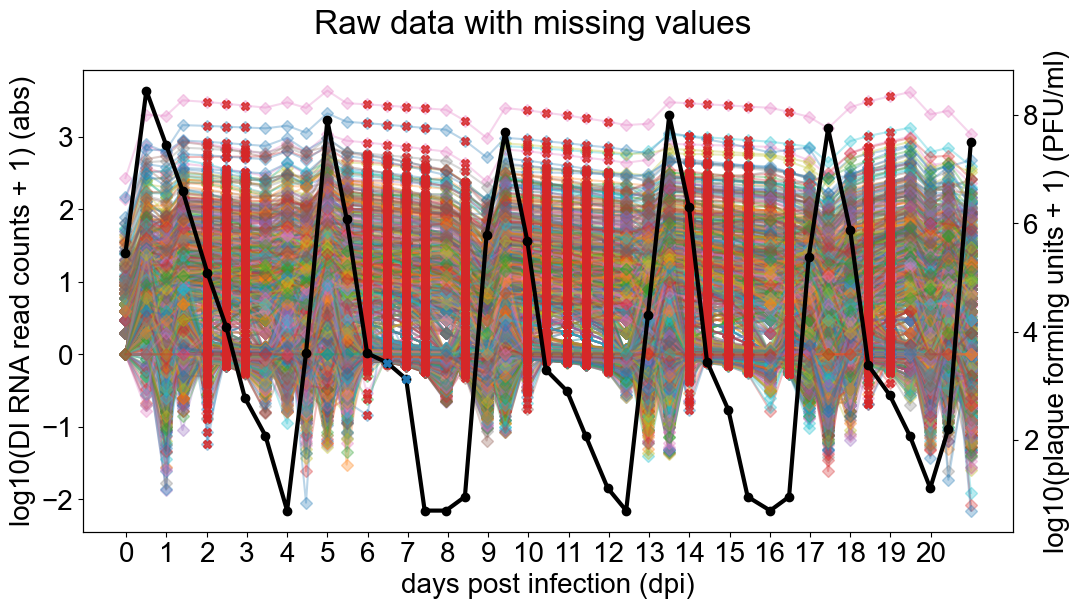

In [20]:
fig, ax = plt.subplots(figsize=(12,6))
ax2 = ax.twinx()
ax.set_xlabel('days post infection (dpi)')
ax.plot(stationary_ts_df.index,stationary_ts_df.drop(columns=['plaque_assay']),
          alpha=0.3, 
          marker='D'
          )
ax.plot(read_counts_missing_timepoints, stationary_ts_df.loc[read_counts_missing_timepoints].drop(columns=['plaque_assay']),
          alpha=0.8, 
          marker='X',
          color='tab:red',
          linewidth=0
          )
ax.set_ylabel('log10(DI RNA read counts + 1) (abs)')
ax2.plot(stationary_ts_df.index, stationary_ts_df['plaque_assay'], 
        color='black', 
        marker='o', 
        label='PFU/ml',
        linewidth=3
        )
ax2.plot(plaque_assay_missing_timepoints, 
        stationary_ts_df.loc[plaque_assay_missing_timepoints]['plaque_assay'],
        marker='X',
        color='tab:blue',
        linewidth=0,
        zorder=10
        )
ax2.set_yscale('linear')
ax2.set_ylabel('log10(plaque forming units + 1) (PFU/ml)')
ax2.set_xticks([range(0, max(stationary_ts_df.index.astype(int))+1)[i] for i in range(0, max(stationary_ts_df.index.astype(int)), 1)])
fig.suptitle('Raw data with missing values')
plt.show()


In [21]:
output_prefix = 'data/outputs/plus1_log10_linear_imputation'
stationary_ts_df.to_csv(f'{output_prefix}/stationary_ts_df.csv')

# Granger-causality test

In [22]:
# importing the granger causality test from statsmodels
from statsmodels.tsa.stattools import grangercausalitytests

# assigning the string 'ssr_chi2test' to the variable 'test'
test = 'ssr_chi2test'
err_dips = {}

In [23]:
def granger_causation_matrix_fixed_lag(data, variables, cultivation_values=[],test='ssr_chi2test', plot=False,fixlag=3, maxlag=3, debug=False):
    test_results = {}
    err_dips = {}
    max_lags = {}
    # creating a dataframe with the same dimensions as number of variables entered, assigned to the variable 'X_train'
    X_train = pd.DataFrame(np.nan, index=variables, columns=variables)
    
    # loops through the columns and the indexes
    for c in X_train.columns:
        for r in X_train.index:
            #skip if we're not looking at any cultivation variable
            if r == c:
                continue
            go_on = False
            if c in cultivation_values:
                go_on = True
            if r in cultivation_values:
                go_on = True
            
            if go_on == False:
                continue
            # conducts a granger causality test on a variable row and column using the 'maxlag' variable; assigns to 
            # variable test_result
            try:
                test_result = grangercausalitytests(data[[r, c]], maxlag=[maxlag], verbose=False)
            except Exception as e:
                if debug:
                  print(f'Error on {r} and {c}, {data[[r, c]]}: {e}')
                err_dips[(r,c)] = e
                X_train.loc[r, c] = None
                max_lags[(r,c)] = None
                continue
            test_results[(r,c)] = test_result    
            # locates the test result in the tuple 'test_result' and rounds the number by 4 digits; assigns to 'p_values'
            p_value = round(test_result[fixlag][0][test][1], 4)
            max_lags[(r,c)] = fixlag
            X_train.loc[r, c] = p_value
            
    # rename the row and column names based on the relationship
    X_train.columns = [var + '_x' for var in variables]
    X_train.index = [var + '_y' for var in variables]
    return X_train, test_results, max_lags, err_dips

In [24]:
from statsmodels.stats.multitest import multipletests

import numpy as np
from statsmodels.stats.multitest import multipletests

import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests

def correct_p_values_bh_separately(matrix, cult_columns=5, alpha=0.05, debug=False):
    """
    Applies Benjamini-Hochberg correction cultivation-column-wise:
    1. DVGs -> each Virus Concentration column (row i, DVG columns to the right)
    2. Each Virus Concentration column -> DVGs (DVG rows, column i)

    Parameters:
        matrix (pd.DataFrame): A pandas DataFrame where each cell contains a p-value.
        cult_columns (int): Number of columns corresponding to virus concentration variables.
        alpha (float): significance level for BH.
        debug (bool): if True, print and display slices being corrected.

    Returns:
        pd.DataFrame: Same shape with BH-adjusted p-values.
    """
    corrected_matrix = matrix.copy()

    for col_i in range(cult_columns):
        col_name = matrix.columns[col_i].replace("_x", "")

        # DVG -> col_i (row col_i, DVG columns to the right)
        dvg_to_col = matrix.iloc[col_i, cult_columns:].values
        if debug:
            print(f"\n[DVG -> {col_name}] slice BEFORE correction:")
            display(matrix.iloc[col_i:col_i+1, cult_columns:])
        mask = ~np.isnan(dvg_to_col)
        if mask.any():
            _, corrected_vals, _, _ = multipletests(dvg_to_col[mask], alpha=alpha, method="fdr_bh")
            tmp = dvg_to_col.copy()
            tmp[mask] = corrected_vals
            corrected_matrix.iloc[col_i, cult_columns:] = tmp
            if debug:
                print(f"[DVG -> {col_name}] slice AFTER correction:")
                display(corrected_matrix.iloc[col_i:col_i+1, cult_columns:])

        # col_i -> DVGs (all DVG rows below, column col_i)
        col_to_dvg = matrix.iloc[cult_columns:, col_i].values
        if debug:
            print(f"\n[{col_name} -> DVGs] slice BEFORE correction:")
            display(matrix.iloc[cult_columns:, col_i:col_i+1])
        mask = ~np.isnan(col_to_dvg)
        if mask.any():
            _, corrected_vals, _, _ = multipletests(col_to_dvg[mask], alpha=alpha, method="fdr_bh")
            tmp = col_to_dvg.copy()
            tmp[mask] = corrected_vals
            corrected_matrix.iloc[cult_columns:, col_i] = tmp
            if debug:
                print(f"[{col_name} -> DVGs] slice AFTER correction:")
                display(corrected_matrix.iloc[cult_columns:, col_i:col_i+1])
    return corrected_matrix

def _bh_critical_pval(pvals, alpha=0.05, debug=False):
    """Return the BH critical p-value for a 1D array (ignoring NaNs)."""
    p = np.sort(np.asarray(pvals)[~np.isnan(pvals)])
    m = p.size
    if m == 0:
        if debug:
            print("No valid p-values found.")
        return None
    thresholds = alpha * (np.arange(1, m+1) / m)
    hits = np.where(p <= thresholds)[0]
    if debug:
      # create df
      tmp_df = pd.DataFrame({'p-values': p, 'thresholds': thresholds})
      tmp_df['hits'] = np.where(p <= thresholds, 'hit', 'miss')
      display(tmp_df)
    if hits.size == 0:
      if debug:
          print("No hits found.")
      return None
    kmax = hits.max()
    if debug:
      print(f"Critical p-value for BH correction at rank {kmax}: {p[kmax]}")
    return p[kmax]   # the largest p-value that still passes

def calculate_critical_pval_bh(matrix, cult_columns=5, alpha=0.05, debug=False):
    """
    For each cultivation column i (0..cult_columns-1), return:
      - 'dvg_to_<colname>': BH critical p for DVGs -> <colname>
        (row i, DVG columns to the right)
      - '<colname>_to_dvg': BH critical p for <colname> -> DVGs
        (DVG rows below, column i)
    """
    crit_dct = {}
    for i, col_name in enumerate(matrix.columns[:cult_columns]):
        clean = col_name.replace('_x', '')

        # DVG -> col_i  (row i, DVG columns)
        dvg_to_col_slice = matrix.iloc[i, cult_columns:]
        if debug:
            print(f"\n[DVG -> {clean}] slice:")
            display(dvg_to_col_slice.to_frame().T)
        dvg_to_col = dvg_to_col_slice.values
        crit_dct[f"dvg_to_{clean}"] = _bh_critical_pval(dvg_to_col, alpha, debug)

        # col_i -> DVGs  (DVG rows, column i)
        col_to_dvg_slice = matrix.iloc[cult_columns:, i]
        if debug:
            print(f"\n[{clean} -> DVGs] slice:")
            display(col_to_dvg_slice.to_frame())
        col_to_dvg = col_to_dvg_slice.values
        crit_dct[f"{clean}_to_dvg"] = _bh_critical_pval(col_to_dvg, alpha, debug)

    return crit_dct

In [25]:
stationary_ts_df = stationary_ts_df.astype('float64')
stationary_ts_df

,plaque_assay,HA_123_1491,HA_126_1560,HA_189_1532,HA_208_1534,HA_47_107,HA_93_1460,M_126_741,M_132_939,M_175_907,...,PB2_91_123,PB2_91_2004,PB2_922_2211,PB2_92_116,PB2_94_122,PB2_961_2065,PB2_97_122,PB2_97_1975,PB2_98_130,PB2_98_2005
-0.02,5.447160,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.579784,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.50,8.447158,0.000000,0.602060,0.763428,0.000000,0.903090,0.000000,-0.778151,0.301030,0.000000,...,1.204120,0.778151,0.000000,0.477121,0.778151,0.000000,0.602060,0.301030,0.954243,0.000000
0.99,7.447158,0.000000,0.000000,-0.119975,0.000000,-0.602060,0.000000,0.602060,1.041393,0.845098,...,0.157608,0.176091,0.301030,0.522879,0.000000,0.602060,0.544068,0.477121,1.041393,0.000000
1.40,6.602060,0.000000,0.000000,0.310790,0.000000,-0.301030,0.000000,0.176091,0.602060,0.000000,...,0.036212,0.124939,0.000000,-0.096910,0.477121,0.903090,0.084321,0.698970,1.079181,0.000000
2.02,5.079185,0.000000,0.000000,-0.079181,0.000000,0.000000,0.000000,-0.057992,0.602060,0.000000,...,-0.045757,-0.009143,0.243038,-0.107210,0.544068,0.860338,0.048305,0.653213,1.122216,0.000000
2.49,4.079217,0.000000,0.000000,-0.096910,0.000000,0.000000,0.000000,-0.066947,0.602060,0.000000,...,-0.051153,-0.009340,0.397940,-0.142668,0.602060,0.812913,0.043466,0.602060,1.161368,0.000000
2.95,2.778874,0.000000,0.000000,-0.124939,0.000000,0.000000,0.000000,-0.079181,0.602060,0.000000,...,-0.057992,-0.009545,0.511883,-0.213880,0.653213,0.759668,0.039509,0.544068,1.197281,0.000000
3.46,2.082785,0.000000,0.000000,-0.176091,0.000000,0.000000,0.000000,-0.096910,0.602060,0.000000,...,-0.066947,-0.009760,0.602060,-0.439333,0.698970,0.698970,0.036212,0.477121,1.230449,0.000000
4.00,0.698970,0.000000,1.322219,0.166331,0.000000,0.000000,0.000000,-0.477121,0.477121,0.000000,...,0.146128,0.104735,0.000000,0.778151,1.000000,0.301030,0.120574,0.698970,0.845098,0.000000
4.47,3.602169,0.000000,0.000000,0.072551,0.000000,0.000000,0.000000,0.000000,0.301030,0.000000,...,-0.419129,-0.104735,0.301030,-0.778151,1.146128,0.477121,-0.217484,0.477121,1.000000,0.000000


## Make Granger-causality matrix

How to read the matrix: column X Granger-causes row Y
i.e. X improves the forecasting performance of Y if included in an OLS model

In [26]:
import pickle
output_prefix = 'data/outputs/plus1_log10_linear_imputation'
if not os.path.exists(output_prefix):
  os.makedirs(output_prefix)
  
gc_matrix = {}
test_results = {}
gc_max_lag = {}
errors = {}

corrected_gc_matrix = {}
bh_critical_p_vals = {}

In [27]:
max_fixed_lag = 4

In [28]:
for fix_lag in range(1,max_fixed_lag):
    print(f'Calculating granger causality matrix for fixed lag {fix_lag}...')
    gc_matrix[fix_lag], test_results[fix_lag], gc_max_lag[fix_lag], errors[fix_lag] = granger_causation_matrix_fixed_lag(
        stationary_ts_df,
        variables=stationary_ts_df.columns.tolist(),
        cultivation_values=['plaque_assay'],
        fixlag=fix_lag,
        maxlag=fix_lag
    )
    
    corrected_gc_matrix[fix_lag] = correct_p_values_bh_separately(
        gc_matrix[fix_lag],
        cult_columns=1,
        alpha=0.05,
        debug=False
    )
    
    bh_critical_p_vals[fix_lag] = calculate_critical_pval_bh(
        gc_matrix[fix_lag],
        cult_columns=1,
        alpha=0.05,
        debug=False
    )

Calculating granger causality matrix for fixed lag 1...


Calculating granger causality matrix for fixed lag 2...
Calculating granger causality matrix for fixed lag 3...


In [29]:
print("critical p-values with BH correction:")
bh_critical_p_vals

critical p-values with BH correction:


{1: {'dvg_to_plaque_assay': 0.0065, 'plaque_assay_to_dvg': 0.0055},
 2: {'dvg_to_plaque_assay': None, 'plaque_assay_to_dvg': 0.009},
 3: {'dvg_to_plaque_assay': None, 'plaque_assay_to_dvg': 0.008}}

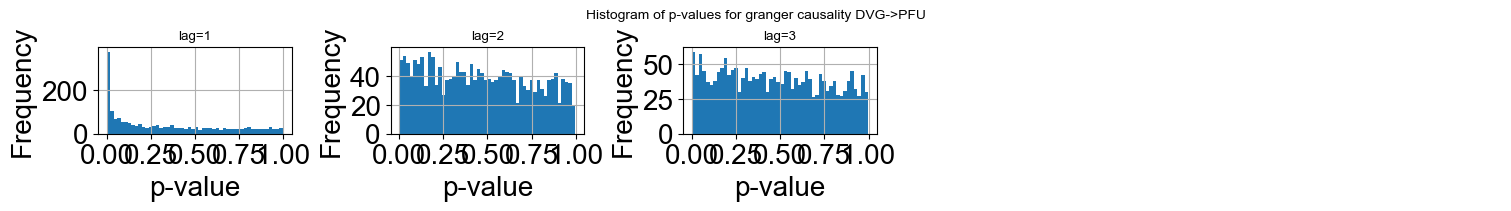

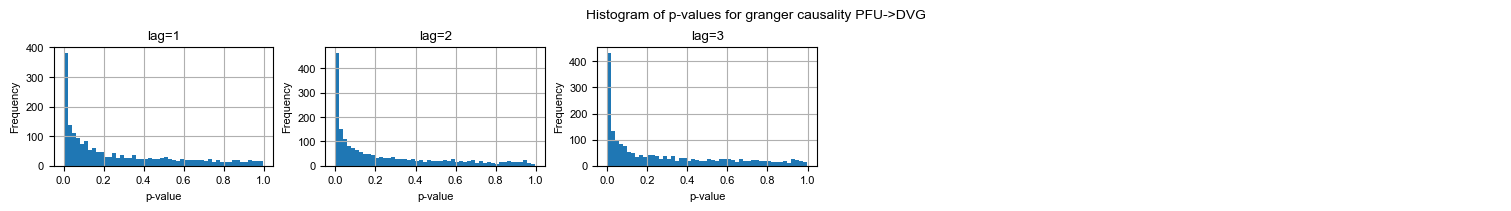

In [30]:
import matplotlib.pyplot as plt
import math

# Calculate grid dimensions (e.g., 3 columns)
n_plots = len(gc_matrix)
cols = 6
rows = math.ceil(n_plots / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 2 * rows), constrained_layout=True)
axes = axes.flatten()  # Flatten to iterate easily

# set font size
plt.rcParams.update({'font.size': 8})

for i, fixlag in enumerate(range(1, n_plots + 1)):
    ax = axes[i]
    
    # Plotting the histogram on the specific axis
    # Note: using fixlag instead of the hardcoded 3 from your snippet
    gc_matrix[fixlag].iloc[0].hist(bins=50, ax=ax)
    
    ax.set_title(f'lag={fixlag}')
    ax.set_xlabel('p-value')
    ax.set_ylabel('Frequency')

# Hide any empty subplots if the grid is larger than the number of lags
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Set the main title for the entire figure
plt.suptitle("Histogram of p-values for granger causality DVG->PFU", fontsize=10)
plt.show()

fig_pfu_to_dvg, axes_pfu_to_dvg = plt.subplots(rows, cols, figsize=(15, 2 * rows), constrained_layout=True)
axes_pfu_to_dvg = axes_pfu_to_dvg.flatten()  # Flatten to iterate easily
for i, fixlag in enumerate(range(1, n_plots + 1)):
    ax = axes_pfu_to_dvg[i]
    
    # Plotting the histogram on the specific axis
    # Note: using fixlag instead of the hardcoded 3 from your snippet
    gc_matrix[fixlag].iloc[1:,0].hist(bins=50, ax=ax)
    
    ax.set_title(f'lag={fixlag}')
    ax.set_xlabel('p-value')
    ax.set_ylabel('Frequency')
# Hide any empty subplots if the grid is larger than the number of lags
for j in range(i + 1, len(axes_pfu_to_dvg)):
    axes_pfu_to_dvg[j].axis('off')
# Set the main title for the entire figure
plt.suptitle("Histogram of p-values for granger causality PFU->DVG", fontsize=10)
plt.show()

## Summarize

In [31]:
def classify_granger_dips(gc_matrix, cultivation_vals):
    granger_caused_dips = {}
    granger_not_caused_dips = {}
    granger_causing_dips = {}
    granger_not_causing_dips = {}
    granger_bi_dips = {}
    non_related_dips = {}
    for cultivation_val in cultivation_vals:
        granger_caused_dips[cultivation_val] = [dip.replace('_y', '') for dip in gc_matrix[gc_matrix[cultivation_val + '_x'] <= 0.05].index]
        granger_not_caused_dips[cultivation_val] = [dip.replace('_y', '') for dip in gc_matrix[gc_matrix[cultivation_val + '_x'] > 0.05].index]
        tmp_y = gc_matrix.loc[cultivation_val + '_y']
        granger_causing_dips[cultivation_val] = [dip.replace('_x', '') for dip in tmp_y[tmp_y <= 0.05].index]
        granger_not_causing_dips[cultivation_val] = [dip.replace('_x', '') for dip in tmp_y[tmp_y > 0.05].index]
        
        granger_bi_dips[cultivation_val] = list(set(granger_causing_dips[cultivation_val]).intersection(set(granger_caused_dips[cultivation_val])))
        non_related_dips[cultivation_val] = list(set(granger_not_caused_dips[cultivation_val]).intersection(set(granger_not_causing_dips[cultivation_val])))
    return granger_caused_dips, granger_causing_dips, granger_bi_dips, non_related_dips
  
def classify_granger_dips_bh(gc_matrix, cultivation_vals, bh_critical_pvals):    
    granger_caused_dips = {}
    granger_not_caused_dips = {}
    granger_causing_dips = {}
    granger_not_causing_dips = {}
    granger_bi_dips = {}
    non_related_dips = {}
    for cultivation_val in cultivation_vals:
        critical_causing_pval = bh_critical_pvals[f"dvg_to_{cultivation_val}"]
        critical_caused_pval = bh_critical_pvals[f"{cultivation_val}_to_dvg"]
        granger_caused_dips[cultivation_val] = [dip.replace('_y', '') for dip in gc_matrix[gc_matrix[cultivation_val + '_x'] <= critical_caused_pval].index]
        granger_not_caused_dips[cultivation_val] = [dip.replace('_y', '') for dip in gc_matrix[gc_matrix[cultivation_val + '_x'] > critical_caused_pval].index]
        tmp_y = gc_matrix.loc[cultivation_val + '_y']
        granger_causing_dips[cultivation_val] = [dip.replace('_x', '') for dip in tmp_y[tmp_y <= critical_causing_pval].index]
        granger_not_causing_dips[cultivation_val] = [dip.replace('_x', '') for dip in tmp_y[tmp_y > critical_causing_pval].index]
        
        granger_bi_dips[cultivation_val] = list(set(granger_causing_dips[cultivation_val]).intersection(set(granger_caused_dips[cultivation_val])))
        non_related_dips[cultivation_val] = list(set(granger_not_caused_dips[cultivation_val]).intersection(set(granger_not_causing_dips[cultivation_val])))
    return granger_caused_dips, granger_causing_dips, granger_bi_dips, non_related_dips
        

In [32]:
granger_caused_dips = {}
granger_causing_dips = {}
granger_bi_dips = {}
non_related_dips = {}

granger_caused_dips_bh = {}
granger_causing_dips_bh = {}
granger_bi_dips_bh = {}
non_related_dips_bh = {}

granger_caused_dips_corrected = {}
granger_causing_dips_corrected = {}
granger_bi_dips_corrected = {}
non_related_dips_corrected = {}

In [33]:
for fix_lag in range(1,max_fixed_lag):
  granger_caused_dips[fix_lag], granger_causing_dips[fix_lag], granger_bi_dips[fix_lag], non_related_dips[fix_lag] = classify_granger_dips(
      gc_matrix[fix_lag],
      cultivation_vals=['plaque_assay']
  )
  
  granger_caused_dips_bh[fix_lag], granger_causing_dips_bh[fix_lag], granger_bi_dips_bh[fix_lag], non_related_dips_bh[fix_lag] = classify_granger_dips_bh(
      gc_matrix[fix_lag],
      cultivation_vals=['plaque_assay'],
      bh_critical_pvals=bh_critical_p_vals[fix_lag]
  )
  
  granger_caused_dips_corrected[fix_lag], granger_causing_dips_corrected[fix_lag], granger_bi_dips_corrected[fix_lag], non_related_dips_corrected[fix_lag] = classify_granger_dips(
      corrected_gc_matrix[fix_lag],
      cultivation_vals=['plaque_assay']
  )


In [34]:
def create_summary_df(gc_test_results, 
                      gc_max_lag,
                      granger_caused_dips, granger_causing_dips, granger_bi_dips, non_related_dips,
                      diff_level_dct,
                      readcounts_data,
                      time_series_data,
                      output_file, 
                      stat_tests=['ssr_ftest', 'ssr_chi2test', 'lrtest'],
                      cultivation_values=['vrna', 'tcid50', 'plaque_assay', 'log_ha', 'ha_titer']):
    
    # Collect all unique DIPs that were tested (including non-related)
    all_tested_dips = set(
        dip for dips in granger_caused_dips.values() for dip in dips
    ).union(
        dip for dips in granger_causing_dips.values() for dip in dips
    ).union(
        dip for dips in non_related_dips.values() for dip in dips
    )

    # Initialize summary dataframe with filtered keys
    summary_df = readcounts_data[readcounts_data['key'].isin(all_tested_dips)][['key']].copy()
    
    # Assign Granger causality labels
    for cultivation_value in cultivation_values:
        summary_df[cultivation_value + '_granger_label'] = summary_df['key'].apply(
            lambda dip: (
                'bi-directional' if dip in granger_bi_dips.get(cultivation_value, [])
                else 'causing' if dip in granger_causing_dips.get(cultivation_value, [])
                else 'caused' if dip in granger_caused_dips.get(cultivation_value, [])
                else 'non-related' if dip in non_related_dips.get(cultivation_value, []) 
                else None  # DIPs that were never processed
            )
        )
    
    # Store max_diff level
    summary_df['max_diff'] = summary_df['key'].map(diff_level_dct).fillna(0)
    
    # Function to extract Granger test statistics (Unchanged)
    def extract_granger_stats(key, cultivation_value, direction):
        """Extracts Granger test statistics, lags, and correlation values."""
        tr_key = (cultivation_value, key) if direction == 'causing' else (key, cultivation_value)
        
        if tr_key not in gc_test_results or tr_key not in gc_max_lag:
            return None, None, None, [None] * len(stat_tests)
        
        tr = gc_test_results[tr_key]
        max_lag = gc_max_lag[tr_key]
        
        # Extract p-values for each statistical test
        
        stat_pvals = [tr[max_lag][0][test][1] for test in stat_tests]
        
        # Compute cross-correlation
        cross_corr_value = time_series_data[key].corr(
            time_series_data[cultivation_value].shift(-max_lag)  # Always shift as "causing"
        )
        
        return max_lag, cross_corr_value, stat_pvals
    
    # Process each cultivation variable
    for cultivation_value in cultivation_values:
        max_lags, cross_corr_values, significant_pvals_lags = [], [], []
        stat_tests_dct = {test: [] for test in stat_tests}
        
        for key in summary_df['key']:
            granger_label = summary_df.loc[summary_df['key'] == key, cultivation_value + '_granger_label'].values[0]
            
            # Extract Granger stats for all tested DIPs, including "non-related"
            if granger_label is not None:
                direction = 'causing'  # Always using "causing" for now
                
                max_lag, cross_corr, stat_pvals = extract_granger_stats(key, cultivation_value, direction)
                
                max_lags.append(max_lag)
                cross_corr_values.append(cross_corr)
                
                for i, test in enumerate(stat_tests):
                    stat_tests_dct[test].append(stat_pvals[i])
            else:
                # Skip unprocessed dips
                max_lags.append(None)
                cross_corr_values.append(None)
                for test in stat_tests:
                    stat_tests_dct[test].append(None)
        
        # Assign extracted values to dataframe
        summary_df[cultivation_value + '_max_lag'] = max_lags
        summary_df[cultivation_value + '_cross_corr'] = cross_corr_values
        
        for test in stat_tests:
            summary_df[cultivation_value + '_' + test] = stat_tests_dct[test]
        
        summary_df[cultivation_value + '_significant_pvals'] = summary_df[
            [cultivation_value + '_' + test for test in stat_tests]
        ].lt(0.05).sum(axis=1)
    
    # Compute Granger score
    granger_score_columns = [
        col for cultivation_value in cultivation_values 
        for col in [cultivation_value + '_significant_pvals']
    ]
    summary_df['granger_score'] = summary_df[granger_score_columns].sum(axis=1) - summary_df['max_diff']
    
    # Sort by Granger score and max_diff
    summary_df = summary_df.sort_values(by=['granger_score', 'max_diff'], ascending=[False, True])
    
    # Save to CSV
    summary_df.to_csv(output_file, index=False)

    return summary_df

In [35]:
read_counts_df = pd.DataFrame(columns=['key'])
read_counts_df = pd.concat([read_counts_df, stationary_ts_df.T[1:].reset_index().rename(columns={'index': 'key'})], ignore_index=True)
read_counts_df


,key,-0.02,0.5,0.99,1.4,2.02,2.49,2.95,3.46,4.0,...,16.48,16.97,17.45,18.0,18.45,18.98,19.48,19.99,20.44,21.0
0,HA_123_1491,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.477121,0.698970,1.698970,1.716003,1.851258,1.954243,2.037426,1.531479,1.863323,1.000000
1,HA_126_1560,0.0,0.602060,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.322219,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,HA_189_1532,0.0,0.763428,-0.119975,0.310790,-0.079181,-0.096910,-0.124939,-0.176091,0.166331,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,HA_208_1534,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.206568,-0.065817,-0.494850,1.397940,-0.048986,-0.400511,-0.092023,-0.959081,1.365904,-2.082785
4,HA_47_107,0.0,0.903090,-0.602060,-0.301030,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.146128,-0.221849,-0.477121,0.477121,0.577236,0.239373,0.153427,-0.447158,0.278754,-1.278754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1949,PB2_961_2065,0.0,0.000000,0.602060,0.903090,0.860338,0.812913,0.759668,0.698970,0.301030,...,1.000000,1.230449,0.477121,0.698970,0.698970,0.698970,0.698970,0.698970,0.778151,0.477121
1950,PB2_97_122,0.0,0.602060,0.544068,0.084321,0.048305,0.043466,0.039509,0.036212,0.120574,...,0.176091,0.124939,-0.778151,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.301030
1951,PB2_97_1975,0.0,0.301030,0.477121,0.698970,0.653213,0.602060,0.544068,0.477121,0.698970,...,0.740363,0.778151,0.000000,0.000000,0.367977,0.564271,0.698970,0.477121,0.000000,0.000000
1952,PB2_98_130,0.0,0.954243,1.041393,1.079181,1.122216,1.161368,1.197281,1.230449,0.845098,...,0.397940,0.301030,0.000000,0.602060,0.669007,0.726999,0.778151,0.903090,0.301030,0.301030


In [36]:
summary_df = {}
summary_df_corrected = {}
summary_df_bh = {}


In [37]:
for fixlag in range(1, max_fixed_lag):
  summary_df[fixlag] = create_summary_df(
      gc_test_results=test_results[fixlag],
      gc_max_lag=gc_max_lag[fixlag],
      granger_causing_dips=granger_causing_dips[fixlag],
      granger_caused_dips=granger_caused_dips[fixlag],
      granger_bi_dips=granger_bi_dips[fixlag],
      non_related_dips=non_related_dips[fixlag],
      diff_level_dct=stationarity_results.diff_levels.to_dict(),
      readcounts_data=read_counts_df,
      time_series_data=stationary_ts_df,
      output_file=f'{output_prefix}/gc_summary_df_lag{fixlag}.csv',
      stat_tests=['ssr_ftest', 'ssr_chi2test', 'lrtest'],
      cultivation_values=['plaque_assay']   
  )
  
  summary_df_corrected[fixlag] = create_summary_df(
      gc_test_results=test_results[fixlag],
      gc_max_lag=gc_max_lag[fixlag],
      granger_causing_dips=granger_causing_dips_corrected[fixlag],
      granger_caused_dips=granger_caused_dips_corrected[fixlag],
      granger_bi_dips=granger_bi_dips_corrected[fixlag],
      non_related_dips=non_related_dips_corrected[fixlag],
      diff_level_dct=stationarity_results.diff_levels.to_dict(),
      readcounts_data=read_counts_df,
      time_series_data=stationary_ts_df,
      output_file=f'{output_prefix}/gc_summary_df_corrected_lag{fixlag}.csv',
      stat_tests=['ssr_ftest', 'ssr_chi2test', 'lrtest'],
      cultivation_values=['plaque_assay']   
  )
  
  summary_df_bh[fixlag] = create_summary_df(
      gc_test_results=test_results[fixlag],
      gc_max_lag=gc_max_lag[fixlag],
      granger_causing_dips=granger_causing_dips_bh[fixlag],
      granger_caused_dips=granger_caused_dips_bh[fixlag],
      granger_bi_dips=granger_bi_dips_bh[fixlag],
      non_related_dips=non_related_dips_bh[fixlag],
      diff_level_dct=stationarity_results.diff_levels.to_dict(),
      readcounts_data=read_counts_df,
      time_series_data=stationary_ts_df,
      output_file=f'{output_prefix}/gc_summary_df_bh_lag{fixlag}.csv',
      stat_tests=['ssr_ftest', 'ssr_chi2test', 'lrtest'],
      cultivation_values=['plaque_assay']   
  )

In [38]:
summary_df[1]

,key,plaque_assay_granger_label,max_diff,plaque_assay_max_lag,plaque_assay_cross_corr,plaque_assay_ssr_ftest,plaque_assay_ssr_chi2test,plaque_assay_lrtest,plaque_assay_significant_pvals,granger_score
7,M_132_939,bi-directional,0.0,1,-0.214176,0.008163,0.003818,0.005736,3,3.0
9,NA_175_1066,bi-directional,0.0,1,0.023001,0.002160,0.000652,0.001359,3,3.0
26,PA_120_147,bi-directional,0.0,1,-0.383750,0.013076,0.006958,0.009550,3,3.0
28,PA_120_164,bi-directional,0.0,1,-0.426089,0.000276,0.000034,0.000146,3,3.0
30,PA_120_172,causing,0.0,1,-0.312403,0.039264,0.026854,0.031330,3,3.0
...,...,...,...,...,...,...,...,...,...,...
1790,PB2_193_2158,non-related,2.0,1,-0.147152,0.343919,0.320097,0.322917,0,-2.0
1848,PB2_2131_2156,non-related,2.0,1,-0.050442,0.834310,0.827015,0.827064,0,-2.0
1866,PB2_2171_2196,non-related,2.0,1,0.002915,0.766279,0.756084,0.756220,0,-2.0
960,PB1_170_2194,non-related,3.0,1,-0.107533,0.674042,0.660085,0.660451,0,-3.0


In [39]:
summary_df[1].plaque_assay_granger_label.value_counts()

plaque_assay_granger_label
non-related       1125
caused             310
bi-directional     268
causing            251
Name: count, dtype: int64

In [40]:
stationary_df = stationary_ts_df.T.copy()
stationary_df

,-0.02,0.50,0.99,1.40,2.02,2.49,2.95,3.46,4.00,4.47,...,16.48,16.97,17.45,18.00,18.45,18.98,19.48,19.99,20.44,21.00
plaque_assay,5.44716,8.447158,7.447158,6.602060,5.079185,4.079217,2.778874,2.082785,0.698970,3.602169,...,0.954243,5.380213,7.748188,5.869232,3.380392,2.833147,2.082785,1.113943,2.206826,7.505150
HA_123_1491,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.477121,0.698970,1.698970,1.716003,1.851258,1.954243,2.037426,1.531479,1.863323,1.000000
HA_126_1560,0.00000,0.602060,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.322219,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HA_189_1532,0.00000,0.763428,-0.119975,0.310790,-0.079181,-0.096910,-0.124939,-0.176091,0.166331,0.072551,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HA_208_1534,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.206568,-0.065817,-0.494850,1.397940,-0.048986,-0.400511,-0.092023,-0.959081,1.365904,-2.082785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PB2_961_2065,0.00000,0.000000,0.602060,0.903090,0.860338,0.812913,0.759668,0.698970,0.301030,0.477121,...,1.000000,1.230449,0.477121,0.698970,0.698970,0.698970,0.698970,0.698970,0.778151,0.477121
PB2_97_122,0.00000,0.602060,0.544068,0.084321,0.048305,0.043466,0.039509,0.036212,0.120574,-0.217484,...,0.176091,0.124939,-0.778151,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.301030
PB2_97_1975,0.00000,0.301030,0.477121,0.698970,0.653213,0.602060,0.544068,0.477121,0.698970,0.477121,...,0.740363,0.778151,0.000000,0.000000,0.367977,0.564271,0.698970,0.477121,0.000000,0.000000
PB2_98_130,0.00000,0.954243,1.041393,1.079181,1.122216,1.161368,1.197281,1.230449,0.845098,1.000000,...,0.397940,0.301030,0.000000,0.602060,0.669007,0.726999,0.778151,0.903090,0.301030,0.301030


In [41]:
with_gc_labels = pd.DataFrame()
with_gc_labels.index = stationary_df.index


In [42]:
key2label = {}
for fixlag in range(1, max_fixed_lag):
  for cultivation_value in ['plaque_assay']:
    for idx, row in summary_df[fixlag].iterrows():
        key = row['key']
        label = row[cultivation_value + '_granger_label']
        if key not in key2label:
            key2label[key] = {}
        key2label[key][f'lag{fixlag}_{cultivation_value}'] = label
        
        with_gc_labels.loc[key, f'lag{fixlag}_{cultivation_value}_granger_label'] = label

with_gc_labels = pd.concat([with_gc_labels, stationary_df], axis=1)


In [43]:
with_gc_labels

,lag1_plaque_assay_granger_label,lag2_plaque_assay_granger_label,lag3_plaque_assay_granger_label,-0.02,0.5,0.99,1.4,2.02,2.49,2.95,...,16.48,16.97,17.45,18.0,18.45,18.98,19.48,19.99,20.44,21.0
plaque_assay,NaN,NaN,NaN,5.44716,8.447158,7.447158,6.602060,5.079185,4.079217,2.778874,...,0.954243,5.380213,7.748188,5.869232,3.380392,2.833147,2.082785,1.113943,2.206826,7.505150
HA_123_1491,non-related,non-related,non-related,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.477121,0.698970,1.698970,1.716003,1.851258,1.954243,2.037426,1.531479,1.863323,1.000000
HA_126_1560,non-related,causing,non-related,0.00000,0.602060,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HA_189_1532,non-related,caused,non-related,0.00000,0.763428,-0.119975,0.310790,-0.079181,-0.096910,-0.124939,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HA_208_1534,non-related,non-related,non-related,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.206568,-0.065817,-0.494850,1.397940,-0.048986,-0.400511,-0.092023,-0.959081,1.365904,-2.082785
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PB2_961_2065,non-related,non-related,non-related,0.00000,0.000000,0.602060,0.903090,0.860338,0.812913,0.759668,...,1.000000,1.230449,0.477121,0.698970,0.698970,0.698970,0.698970,0.698970,0.778151,0.477121
PB2_97_122,non-related,non-related,non-related,0.00000,0.602060,0.544068,0.084321,0.048305,0.043466,0.039509,...,0.176091,0.124939,-0.778151,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.301030
PB2_97_1975,causing,non-related,non-related,0.00000,0.301030,0.477121,0.698970,0.653213,0.602060,0.544068,...,0.740363,0.778151,0.000000,0.000000,0.367977,0.564271,0.698970,0.477121,0.000000,0.000000
PB2_98_130,bi-directional,caused,caused,0.00000,0.954243,1.041393,1.079181,1.122216,1.161368,1.197281,...,0.397940,0.301030,0.000000,0.602060,0.669007,0.726999,0.778151,0.903090,0.301030,0.301030


In [44]:
# drop rows if all cols are NaN
with_gc_labels = with_gc_labels.dropna(subset=with_gc_labels.columns[:max_fixed_lag-1], how='all')
with_gc_labels.to_csv(f'{output_prefix}/dvg_time_series_with_gc_labels.csv')


In [45]:
with_gc_labels

,lag1_plaque_assay_granger_label,lag2_plaque_assay_granger_label,lag3_plaque_assay_granger_label,-0.02,0.5,0.99,1.4,2.02,2.49,2.95,...,16.48,16.97,17.45,18.0,18.45,18.98,19.48,19.99,20.44,21.0
HA_123_1491,non-related,non-related,non-related,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.477121,0.698970,1.698970,1.716003,1.851258,1.954243,2.037426,1.531479,1.863323,1.000000
HA_126_1560,non-related,causing,non-related,0.0,0.602060,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HA_189_1532,non-related,caused,non-related,0.0,0.763428,-0.119975,0.310790,-0.079181,-0.096910,-0.124939,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
HA_208_1534,non-related,non-related,non-related,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.206568,-0.065817,-0.494850,1.397940,-0.048986,-0.400511,-0.092023,-0.959081,1.365904,-2.082785
HA_47_107,non-related,non-related,non-related,0.0,0.903090,-0.602060,-0.301030,0.000000,0.000000,0.000000,...,-0.146128,-0.221849,-0.477121,0.477121,0.577236,0.239373,0.153427,-0.447158,0.278754,-1.278754
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PB2_961_2065,non-related,non-related,non-related,0.0,0.000000,0.602060,0.903090,0.860338,0.812913,0.759668,...,1.000000,1.230449,0.477121,0.698970,0.698970,0.698970,0.698970,0.698970,0.778151,0.477121
PB2_97_122,non-related,non-related,non-related,0.0,0.602060,0.544068,0.084321,0.048305,0.043466,0.039509,...,0.176091,0.124939,-0.778151,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.301030
PB2_97_1975,causing,non-related,non-related,0.0,0.301030,0.477121,0.698970,0.653213,0.602060,0.544068,...,0.740363,0.778151,0.000000,0.000000,0.367977,0.564271,0.698970,0.477121,0.000000,0.000000
PB2_98_130,bi-directional,caused,caused,0.0,0.954243,1.041393,1.079181,1.122216,1.161368,1.197281,...,0.397940,0.301030,0.000000,0.602060,0.669007,0.726999,0.778151,0.903090,0.301030,0.301030


# Plot fitted models

## Functions

### Performance metrics

In [46]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from tslearn.metrics import dtw, dtw_path

from scipy.signal import argrelextrema
from scipy.stats import ttest_ind, mannwhitneyu, shapiro, pearsonr


In [47]:
def nrsme(y_true, y_pred):
    return root_mean_squared_error(y_true, y_pred, squared=False) / (np.max(y_true) - np.min(y_true))

def mase(y_true, y_pred):
    # Calculate naive forecast (shifted by one time step)
    naive_forecast = np.roll(y_true, shift=1)
    # Remove the first element to align with y_true[1:]
    naive_forecast = naive_forecast[1:]
    
    # Calculate MAE of the model
    mae_model = mean_absolute_error(y_true, y_pred)
    # Calculate MAE of the naive forecast
    mae_naive = mean_absolute_error(y_true[1:], naive_forecast)
    
    return mae_model / mae_naive

def find_local_extrema(y, order=1):
    """
    Find indices of local minima and maxima in the array.
    
    Parameters:
    - y: Array of values.
    - order: How many points on each side to use for the comparison to consider a point a local minimum or maximum.
    
    Returns:
    - minima_indices: Indices of local minima.
    - maxima_indices: Indices of local maxima.
    """
    minima_indices = argrelextrema(y, np.less, order=order)[0]
    maxima_indices = argrelextrema(y, np.greater, order=order)[0]
    
    # Check the first and last points manually
    if len(y) > 1:
        if y[0] < y[1]:
            minima_indices = np.insert(minima_indices, 0, 0)
        if y[0] > y[1]:
            maxima_indices = np.insert(maxima_indices, 0, 0)
        if y[-1] < y[-2]:
            minima_indices = np.append(minima_indices, len(y) - 1)
        if y[-1] > y[-2]:
            maxima_indices = np.append(maxima_indices, len(y) - 1)
    
    return minima_indices, maxima_indices

def calculate_weighted_mae(y_true, y_pred, order=1, weight_factor=3):
    """
    Calculate the Weighted Mean Absolute Error (WMAE) with higher weights on local minima and maxima.
    
    Parameters:
    - y_true: Array of true values.
    - y_pred: Array of predicted values.
    - order: Order for finding local minima and maxima.
    - weight_factor: Weight assigned to local minima and maxima.
    
    Returns:
    - wmae: Weighted Mean Absolute Error.
    """
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    # Find local minima and maxima
    minima_indices, maxima_indices = find_local_extrema(y_true_arr, order)
    
    # Initialize weights to 1
    weights = np.ones_like(y_true_arr)
    
    # Assign higher weights to local minima and maxima
    weights[minima_indices] = weight_factor
    weights[maxima_indices] = weight_factor
    
    # Calculate weighted MAE
    wmae = np.sum(weights * np.abs(y_true_arr - y_pred_arr) / np.sum(weights))
    
    return wmae

def calculate_weighted_mape(y_true, y_pred, order=1, weight_factor=3):
    """
    Calculate the Weighted Mean Absolute Percentage Error (WMAPE) with higher weights on local minima and maxima.
    
    Parameters:
    - y_true: Array of true values.
    - y_pred: Array of predicted values.
    - order: Order for finding local minima and maxima.
    - weight_factor: Weight assigned to local minima and maxima.
    
    Returns:
    - wmape: Weighted Mean Absolute Percentage Error.
    """
    y_true_arr = np.array(y_true)
    y_pred_arr = np.array(y_pred)
    # Find local minima and maxima
    minima_indices, maxima_indices = find_local_extrema(y_true_arr, order)
    
    # Initialize weights to 1
    weights = np.ones_like(y_true_arr)
    
    # Assign higher weights to local minima and maxima
    weights[minima_indices] = weight_factor
    weights[maxima_indices] = weight_factor
    
    # Calculate WMAPE
    # To avoid division by zero, we add a small epsilon value to y_true
    epsilon = 1e-10
    wmape = np.sum(weights * np.abs((y_true_arr - y_pred_arr) / (y_true_arr + epsilon))) / np.sum(weights)
    
    return wmape

def dtw_pearson(y_true, y_pred):
    """
    Calculate the Dynamic Time Warping (DTW) aligned Pearson correlation coefficient between two time series.
    
    Parameters:
    - y_true: Array of true values.
    - y_pred: Array of predicted values.
    
    Returns:
    - pearson_corr: The Pearson correlation coefficient between the aligned (warped) y_true and y_pred.
    """
    y_true = np.array(y_true).reshape(-1, 1)
    y_pred = np.array(y_pred).reshape(-1, 1)
    path, dtw_distance = dtw_path(y_true, y_pred)
    aligned_true = np.array([y_true[i] for i, j in path]).flatten()
    aligned_pred = np.array([y_pred[j] for i, j in path]).flatten()
    pearson_corr = pearsonr(aligned_true, aligned_pred)[0]
    return pearson_corr

def dtw_mape(y_true, y_pred, epsilon=1e-6):
    """
    Calculate the DTW-aligned Mean Absolute Percentage Error (MAPE) between two time series.
    
    Parameters:
    - y_true: Array of true values.
    - y_pred: Array of predicted values.
    - epsilon: Small constant to avoid division by zero in MAPE calculation.
    
    Returns:
    - dtw_distance: The DTW distance between y_true and y_pred.
    - dtw_aligned_mape: The MAPE calculated on the DTW-aligned series.
    """
    y_true = np.array(y_true).reshape(-1, 1)
    y_pred = np.array(y_pred).reshape(-1, 1)
    
    # Calculate DTW path and distance
    path, dtw_distance = dtw_path(y_true, y_pred)
    
    # Extract aligned series
    aligned_true = np.array([y_true[i] for i, j in path]).flatten()
    aligned_pred = np.array([y_pred[j] for i, j in path]).flatten()
    
    # Calculate MAPE on aligned series
    dtw_aligned_mape = np.mean(np.abs((aligned_true - aligned_pred) / (aligned_true + epsilon))) * 100
    
    return dtw_aligned_mape



### Plot single fits

In [48]:
granger_label_color_map = {
  'non-related': 'gray',
  'causing': 'tab:blue',
  'caused': 'tab:red',
  'bi-directional': 'tab:purple'
}

def run_granger_prediction(
    summary_df,
    gc_max_lag,
    gc_test_results,
    plot_dips,
    log_long_data,
    restricted_pred_index=None,
    include_ssr=False,
    figsize=(8,6),
    ylabel='log10(PFU)',
    xlabel='Time post infection (days)',
    cultivation_value_label='plaque_assay',
    retransform=False,
    yscale='linear'
):
    # Initialize data structures
    columns = ['key', 'granger_label', 'optimal_lag', 'diff_level', 'ssr_chi2test_pval', 'significant_pvals',
                'mape', 'mae', 'rmse', 'nrsme', 'mse', 'dtw', 'wmae', 'wmape', 'relative_mape',
                'relative_rmse', 'relative_mae', 'relative_wmae', 'relative_wmape', 'relative_dtw',
                'relative_mse', 'dtw_aligned_mape', 'ssr', 'weighted_ssr', 'pred_data']

    gc_prediction_summary_tmp = pd.DataFrame(columns=columns)
    ref_ols_performance_dct_tmp = {}
    full_preds = {}

    # Prepare dataframe
    summary_df_cp = summary_df.copy()
    summary_df_cp[f'{cultivation_value_label}_granger_label'] = summary_df_cp[f'{cultivation_value_label}_granger_label'].fillna('non-related')

    if retransform:
      # retransform all time series data
      log_long_data = np.power(10, log_long_data)
    restricted_pred_done = False
    for idx, row in summary_df_cp.iterrows():
        dip = row.key
        opt_lag = gc_max_lag[(cultivation_value_label, dip)]
        full_pred = gc_test_results[cultivation_value_label, dip][opt_lag][1][1].predict()
        if retransform:
          full_pred = np.power(10, full_pred)
          
        if not restricted_pred_done:
          restricted_pred_index = idx if restricted_pred_index is None else restricted_pred_index
          restricted_pred = gc_test_results[cultivation_value_label, dip][opt_lag][1][0].predict()
          if retransform:
            # Retransform predictions if necessary
            restricted_pred = np.power(10, restricted_pred)
          restricted_pred_done = True
                
        full_preds[dip] = full_pred
        actual_value = log_long_data[cultivation_value_label]
        actual_value_comp = actual_value.iloc[opt_lag:]

        dpis = log_long_data.index.values

        metrics = {
              'mape': mean_absolute_percentage_error(actual_value_comp, full_pred),
              'mae': mean_absolute_error(actual_value_comp, full_pred),
              'mse': root_mean_squared_error(actual_value_comp, full_pred)**2
          }

        metrics['rmse'] = np.sqrt(metrics['mse'])
        metrics['nrsme'] = metrics['rmse'] / np.mean(actual_value)
        metrics['dtw'] = dtw(actual_value_comp, full_pred)
        metrics['wmae'] = calculate_weighted_mae(actual_value_comp, full_pred)
        metrics['wmape'] = calculate_weighted_mape(actual_value_comp, full_pred)

        # Relative errors
        rel_metrics = {
            'relative_mape': metrics['mape'] / mean_absolute_percentage_error(actual_value_comp, restricted_pred),
            'relative_rmse': metrics['rmse'] / root_mean_squared_error(actual_value_comp, restricted_pred),
            'relative_mae': metrics['mae'] / mean_absolute_error(actual_value_comp, restricted_pred),
            'relative_wmae': metrics['wmae'] / calculate_weighted_mae(actual_value_comp, restricted_pred),
            'relative_wmape': metrics['wmape'] / calculate_weighted_mape(actual_value_comp, restricted_pred),
            'relative_dtw': metrics['dtw'] / dtw(actual_value_comp, restricted_pred),
            'relative_mse': metrics['mse'] / root_mean_squared_error(actual_value_comp, restricted_pred)**2
        }

        ssr_value = np.sum((actual_value_comp - full_pred) ** 2) if include_ssr else None
        weighted_ssr = np.sum(((actual_value_comp - full_pred)/max(actual_value_comp)) ** 2) / len(full_pred) if include_ssr else None
        
        gc_prediction_summary_tmp.loc[len(gc_prediction_summary_tmp)] = [
            dip, 
            row[f'{cultivation_value_label}_granger_label'], opt_lag, row['max_diff'], row[f'{cultivation_value_label}_ssr_chi2test'],
            row[f'{cultivation_value_label}_significant_pvals'], metrics['mape'], metrics['mae'], metrics['rmse'],
            metrics['nrsme'], metrics['mse'], metrics['dtw'], metrics['wmae'], metrics['wmape'],
            rel_metrics['relative_mape'], rel_metrics['relative_rmse'], rel_metrics['relative_mae'],
            rel_metrics['relative_wmae'], rel_metrics['relative_wmape'], rel_metrics['relative_dtw'],
            rel_metrics['relative_mse'], dtw_mape(actual_value_comp, full_pred),
            ssr_value if include_ssr else None, 
            weighted_ssr if include_ssr else None,
            (dpis[opt_lag:], full_pred)
        ]

        # Save reference metrics for restricted prediction
        if idx == restricted_pred_index:
            for metric in ['mape', 'mae', 'rmse', 'nrsme', 'mse', 'dtw', 'wmae', 'wmape']:
                ref_ols_performance_dct_tmp[metric.upper()] = metrics[metric]
            ref_ols_performance_dct_tmp['DTW_ALIGNED_MAPE'] = dtw_mape(actual_value_comp, restricted_pred)
            if include_ssr:
                ref_ols_performance_dct_tmp['SSR'] = np.sum((actual_value_comp - restricted_pred) ** 2)
                ref_ols_performance_dct_tmp['WEIGHTED_SSR'] = np.sum(((actual_value_comp - restricted_pred)/actual_value_comp) ** 2) / len(restricted_pred)

        # Plot if dip is in plot_dips
        if dip in plot_dips:
            granger_label = row[f'{cultivation_value_label}_granger_label']
            fig, ax = plt.subplots(figsize=(figsize))
            ax.plot(dpis, actual_value, label=f'Real {cultivation_value_label}', marker='D', color='black')
            ax.plot(dpis[opt_lag:], restricted_pred, label='Restricted\nmodel prediction', marker='o', color='#e09312', linewidth=4)
            ax.plot(dpis[opt_lag:], full_pred, label=f'Full model\nprediction with\n{dip}', marker='o', color=granger_label_color_map[granger_label], linewidth=4)
            ax.set_title(f'Prediction with Granger-{row[f"{cultivation_value_label}_granger_label"]} DIP (lag={opt_lag})')
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabel)
            ax.legend(loc='center left', bbox_to_anchor=(1, 0.6))
            ax.set_yscale(yscale)
            fig.text(1.15, -0.1, f'SSR$_{{full}}$={ssr_value:.2f}', 
              transform=ax.transAxes,
              verticalalignment='top',
              bbox=dict(boxstyle='square', facecolor=granger_label_color_map[granger_label], alpha=0.5))
            fig.text(1.15, 0.1, f'SSR$_{{restricted}}$={ref_ols_performance_dct_tmp["SSR"]:.2f}', 
              transform=ax.transAxes,
              verticalalignment='top',
              bbox=dict(boxstyle='square', facecolor='#e09312', alpha=0.5))
            plt.show()
            
    # For color correction later
    gc_prediction_summary_tmp['norm_ssr_chi2test_pval'] = gc_prediction_summary_tmp['ssr_chi2test_pval'] / 0.1
    
    # Group the DataFrame by 'granger_label'
    grouped = gc_prediction_summary_tmp.groupby('granger_label')
    gc_prediction_summary_tmp['group_norm_ssr_chi2test_pval'] = gc_prediction_summary_tmp['ssr_chi2test_pval']
    # Normalize the 'norm_ssr_chi2test' column within each group
    for label, group in grouped:
        max_value = group['group_norm_ssr_chi2test_pval'].max()  # Get the maximum value in the group
        gc_prediction_summary_tmp.loc[group.index, 'group_norm_ssr_chi2test_pval'] = group['group_norm_ssr_chi2test_pval'] / max_value  # Normalize
    
    return gc_prediction_summary_tmp, ref_ols_performance_dct_tmp

## Fitting and plotting

### all

In [49]:
summary_df[1]

,key,plaque_assay_granger_label,max_diff,plaque_assay_max_lag,plaque_assay_cross_corr,plaque_assay_ssr_ftest,plaque_assay_ssr_chi2test,plaque_assay_lrtest,plaque_assay_significant_pvals,granger_score
7,M_132_939,bi-directional,0.0,1,-0.214176,0.008163,0.003818,0.005736,3,3.0
9,NA_175_1066,bi-directional,0.0,1,0.023001,0.002160,0.000652,0.001359,3,3.0
26,PA_120_147,bi-directional,0.0,1,-0.383750,0.013076,0.006958,0.009550,3,3.0
28,PA_120_164,bi-directional,0.0,1,-0.426089,0.000276,0.000034,0.000146,3,3.0
30,PA_120_172,causing,0.0,1,-0.312403,0.039264,0.026854,0.031330,3,3.0
...,...,...,...,...,...,...,...,...,...,...
1790,PB2_193_2158,non-related,2.0,1,-0.147152,0.343919,0.320097,0.322917,0,-2.0
1848,PB2_2131_2156,non-related,2.0,1,-0.050442,0.834310,0.827015,0.827064,0,-2.0
1866,PB2_2171_2196,non-related,2.0,1,0.002915,0.766279,0.756084,0.756220,0,-2.0
960,PB1_170_2194,non-related,3.0,1,-0.107533,0.674042,0.660085,0.660451,0,-3.0


Running granger prediction analysis for lag 1...


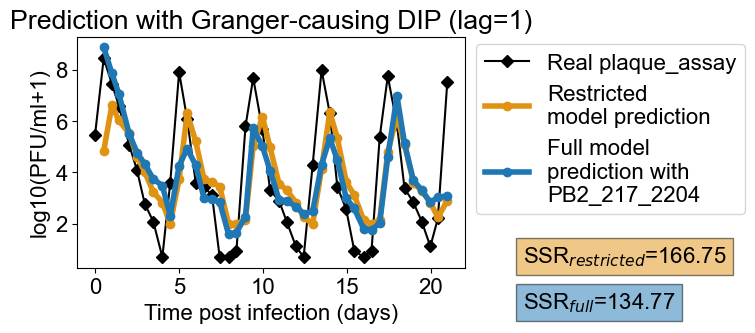

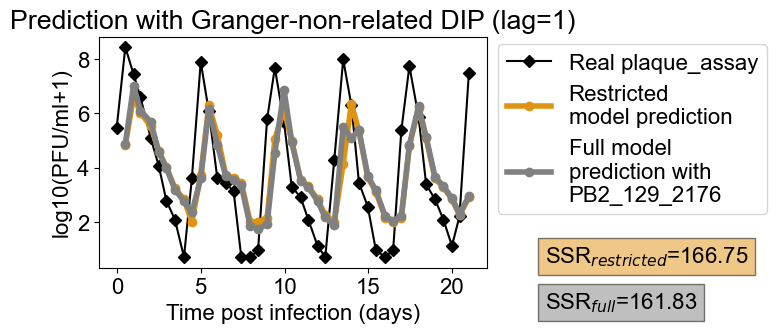

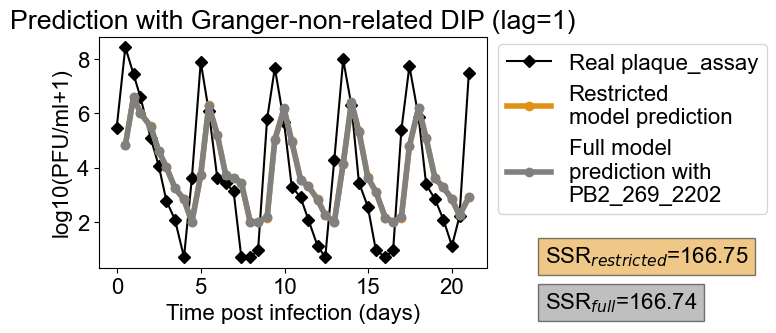

Running granger prediction analysis for lag 2...


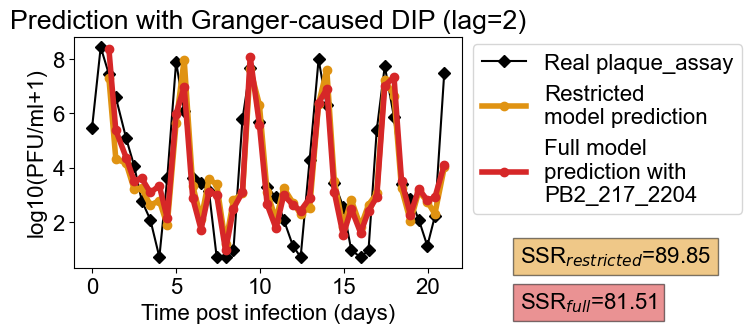

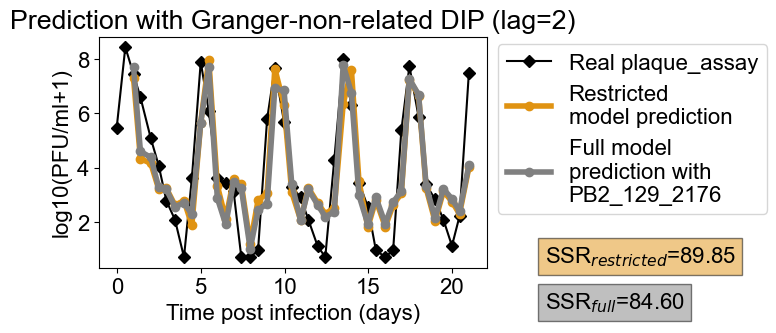

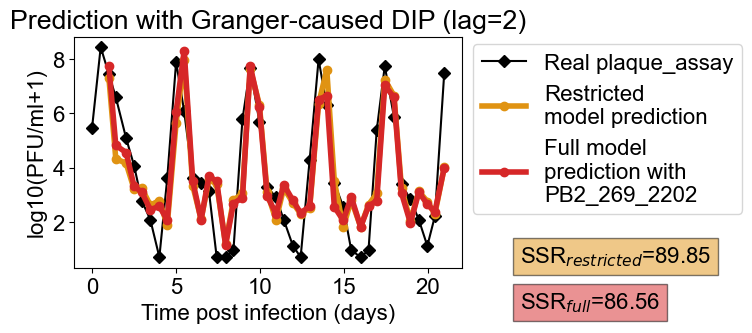

Running granger prediction analysis for lag 3...


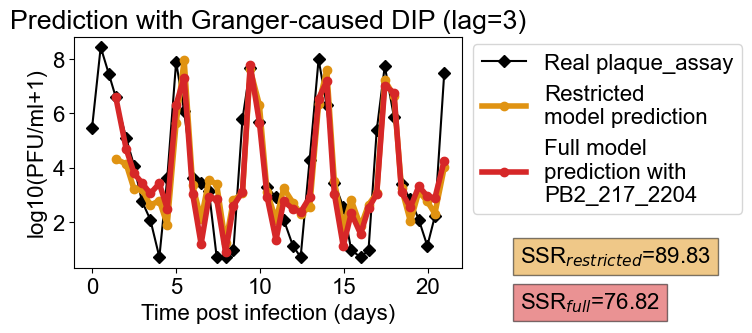

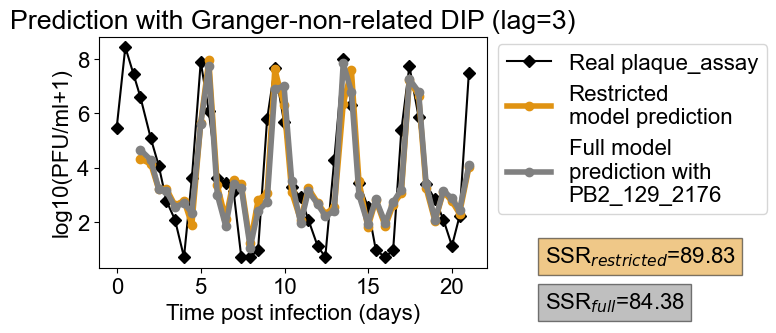

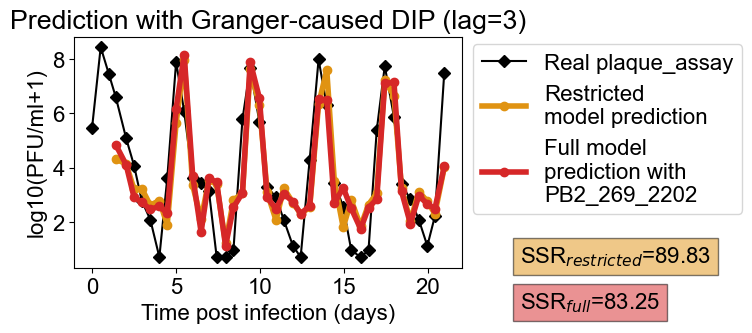

In [50]:
plt.rcParams.update({'font.size': 16})
gc_prediction_summary = {}
ref_ols_performance_dct = {}
for fixlag in range(1, max_fixed_lag):
  print(f'Running granger prediction analysis for lag {fixlag}...')
  ref_ols_performance_dct[fixlag] = {}
  gc_prediction_summary[fixlag], ref_ols_performance_dct[fixlag] = run_granger_prediction(
      summary_df=summary_df[fixlag],
      gc_max_lag=gc_max_lag[fixlag],
      gc_test_results=test_results[fixlag],
      plot_dips=['PB2_129_2176', 'PB2_269_2202', 'PB2_217_2204'
                #,'PA_1989_2027','PA_172_1938', 'PA_124_1974', 'PA_142_1951'
                ],
      log_long_data=stationary_ts_df,
      restricted_pred_index=summary_df[fixlag].iloc[0].name,
      include_ssr=True,
      figsize=(5,3),
      ylabel='log10(PFU/ml+1)'
  )

### corrected

Running granger prediction analysis with p-value correction for lag 1...


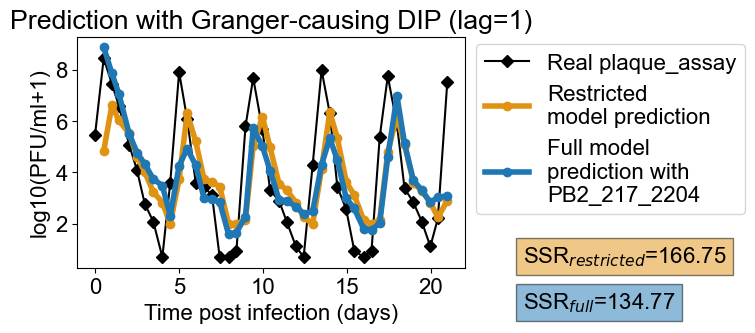

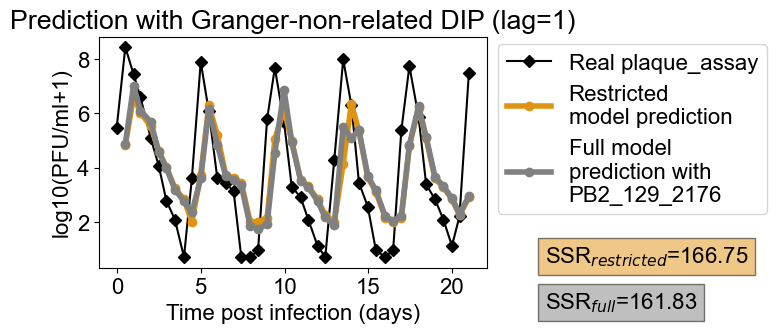

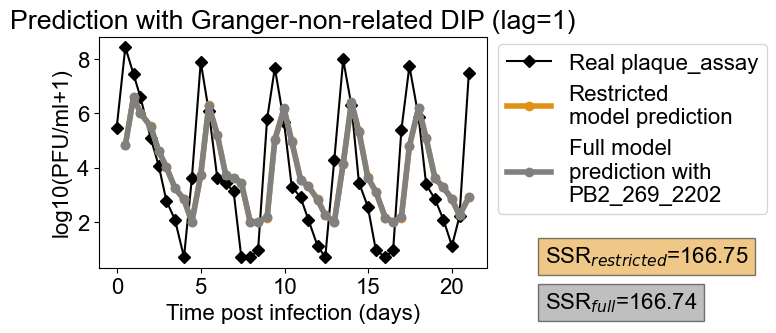

Running granger prediction analysis with p-value correction for lag 2...


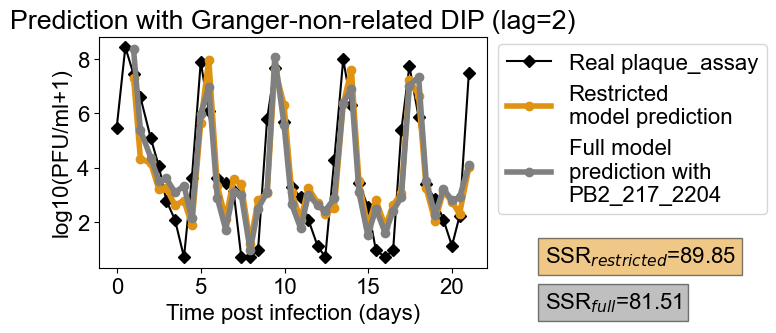

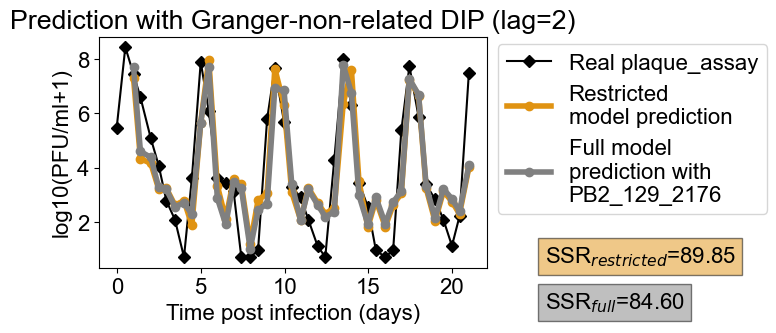

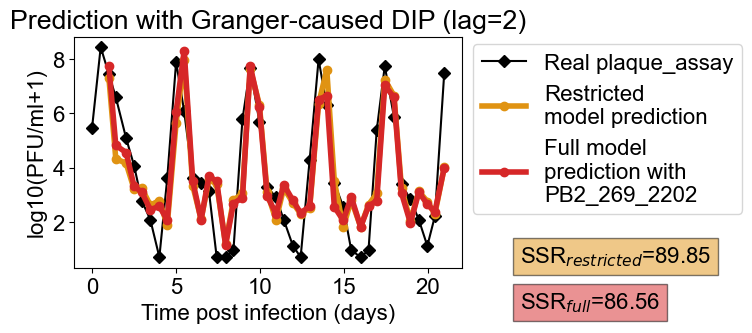

Running granger prediction analysis with p-value correction for lag 3...


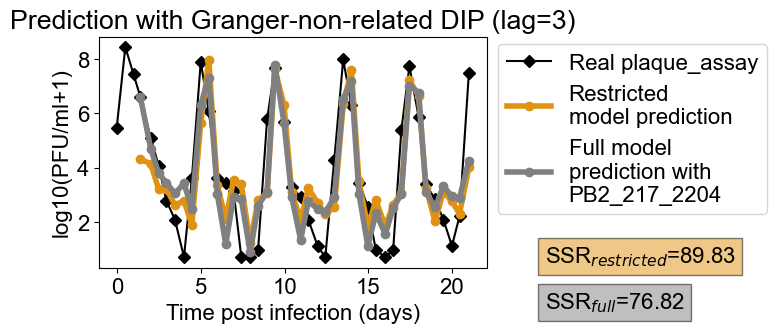

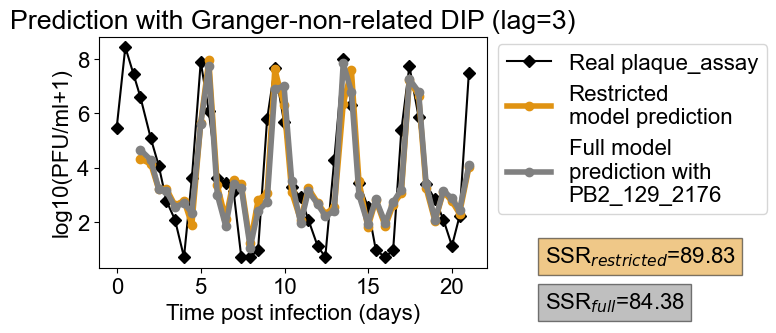

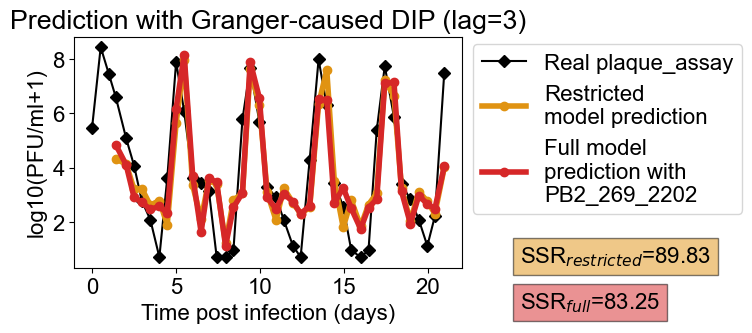

In [51]:
gc_prediction_summary_corrected = {}
ref_ols_performance_corrected_dct = {}
for fixlag in range(1, max_fixed_lag):
  print(f'Running granger prediction analysis with p-value correction for lag {fixlag}...')
  gc_prediction_summary_corrected[fixlag], ref_ols_performance_corrected_dct[fixlag] = run_granger_prediction(
      summary_df=summary_df_corrected[fixlag],
      gc_max_lag=gc_max_lag[fixlag],
      gc_test_results=test_results[fixlag],
      log_long_data=stationary_ts_df,
      restricted_pred_index=summary_df_corrected[fixlag].iloc[0].name,
      include_ssr=True,
      plot_dips=["PB2_129_2176", "PB2_269_2202", "PB2_217_2204"],
      figsize=(5,3), ylabel='log10(PFU/ml+1)'
  )

## plot single candidates

In [52]:
summary_df[1]

,key,plaque_assay_granger_label,max_diff,plaque_assay_max_lag,plaque_assay_cross_corr,plaque_assay_ssr_ftest,plaque_assay_ssr_chi2test,plaque_assay_lrtest,plaque_assay_significant_pvals,granger_score
7,M_132_939,bi-directional,0.0,1,-0.214176,0.008163,0.003818,0.005736,3,3.0
9,NA_175_1066,bi-directional,0.0,1,0.023001,0.002160,0.000652,0.001359,3,3.0
26,PA_120_147,bi-directional,0.0,1,-0.383750,0.013076,0.006958,0.009550,3,3.0
28,PA_120_164,bi-directional,0.0,1,-0.426089,0.000276,0.000034,0.000146,3,3.0
30,PA_120_172,causing,0.0,1,-0.312403,0.039264,0.026854,0.031330,3,3.0
...,...,...,...,...,...,...,...,...,...,...
1790,PB2_193_2158,non-related,2.0,1,-0.147152,0.343919,0.320097,0.322917,0,-2.0
1848,PB2_2131_2156,non-related,2.0,1,-0.050442,0.834310,0.827015,0.827064,0,-2.0
1866,PB2_2171_2196,non-related,2.0,1,0.002915,0.766279,0.756084,0.756220,0,-2.0
960,PB1_170_2194,non-related,3.0,1,-0.107533,0.674042,0.660085,0.660451,0,-3.0


In [53]:
def plot_single_candidate(cultivation_value_label ='plaque_assay',
                          dpis = stationary_ts_df.index.values,
                          row = summary_df[1].sort_values(by='plaque_assay_ssr_chi2test').iloc[0],
                          figsize = (7, 5),
                          xlabel = 'Time post infection (days)',
                          ylabel = 'log10(PFU)',
                          yscale = 'linear',
                          opt_lag = 2,
                          gc_prediction_summary_df = gc_prediction_summary[1],
                          gc_test_results= test_results[1],
                          log_long_data = stationary_ts_df):
  restricted_pred = gc_test_results[(cultivation_value_label, row.key)][row.plaque_assay_max_lag][1][0].predict()
  full_pred = gc_test_results[(cultivation_value_label, row.key)][row.plaque_assay_max_lag][1][1].predict()
  granger_label = row[f'{cultivation_value_label}_granger_label']
  actual_value = log_long_data[cultivation_value_label]
  dip = row.key
  restr_ssr = gc_test_results[(cultivation_value_label, row.key)][row.plaque_assay_max_lag][1][0].ssr
  full_ssr = gc_test_results[(cultivation_value_label, row.key)][row.plaque_assay_max_lag][1][1].ssr
  print(gc_prediction_summary_df[gc_prediction_summary_df.key == dip].iloc[0]['ssr'])

  fig, ax = plt.subplots(figsize=(figsize))
  ax.plot(dpis, actual_value, label=f'Real {cultivation_value_label}', marker='D', color='black')
  ax.plot(dpis[opt_lag:], restricted_pred, label='Restricted\nmodel prediction', marker='o', color='#e09312', linewidth=4)
  ax.plot(dpis[opt_lag:], full_pred, label=f'Full model\nprediction with\n{dip}', marker='o', color=granger_label_color_map[granger_label], linewidth=4)
  ax.set_title(f'Prediction with Granger-{row[f"{cultivation_value_label}_granger_label"]} DIP (lag={opt_lag})')
  ax.set_xlabel(xlabel)
  ax.set_ylabel(ylabel)
  ax.legend(loc='center left', bbox_to_anchor=(1, 0.6))
  ax.set_yscale(yscale)
  fig.text(1.15, -0.1, f'SSR$_{{full}}$={full_ssr:.2f}', 
            transform=ax.transAxes,
            verticalalignment='top',
            bbox=dict(boxstyle='square', facecolor=granger_label_color_map[granger_label], alpha=0.5))
  fig.text(1.15, 0.1, f'SSR$_{{restricted}}$={restr_ssr:.2f}', 
            transform=ax.transAxes,
            verticalalignment='top',
            bbox=dict(boxstyle='square', facecolor='#e09312', alpha=0.5))
  plt.show()
  
def plot_restricted_only(cultivation_value_label ='plaque_assay',
                          dpis = stationary_ts_df.index.values,
                          row = summary_df[1].sort_values(by='plaque_assay_ssr_chi2test').iloc[0],
                          figsize = (7, 5),
                          xlabel = 'Time post infection (days)',
                          ylabel = 'log10(PFU)',
                          yscale = 'linear',
                          opt_lag = 2,
                          gc_prediction_summary_df = gc_prediction_summary[1],
                          gc_test_results= test_results[1],
                          log_long_data = stationary_ts_df):
  restricted_pred = gc_test_results[(cultivation_value_label, row.key)][row.plaque_assay_max_lag][1][0].predict()
  actual_value = log_long_data[cultivation_value_label]
  dip = row.key

  fig, ax = plt.subplots(figsize=(figsize))
  ax.plot(dpis, actual_value, label=f'{cultivation_value_label}', marker='D', color='black')
  ax.plot(dpis[opt_lag:], restricted_pred, label='Restricted\nmodel prediction', marker='o', color='#e09312', linewidth=4)
  ax.set_title(f'Restricted model prediction (lag={opt_lag})')
  ax.set_xlabel(xlabel)
  ax.set_ylabel(ylabel)
  ax.legend(['$\mathregular{c_{virus}}$', 'Restricted model'], loc='center left', bbox_to_anchor=(1, 0.6))
  ax.set_yscale(yscale)
  plt.show()


In [54]:
test_results[1][('PA_172_1938', 'plaque_assay')]

{1: ({'ssr_ftest': (21.954526889952547, 3.3598572191032524e-05, 39.0, 1),
   'ssr_chi2test': (23.64333665071813, 1.1594669328559433e-06, 1),
   'lrtest': (18.75579212762358, 1.485714244147246e-05, 1),
   'params_ftest': (21.95452688995234, 3.359857219103477e-05, 39.0, 1.0)},
   array([[0., 1., 0.]])])}

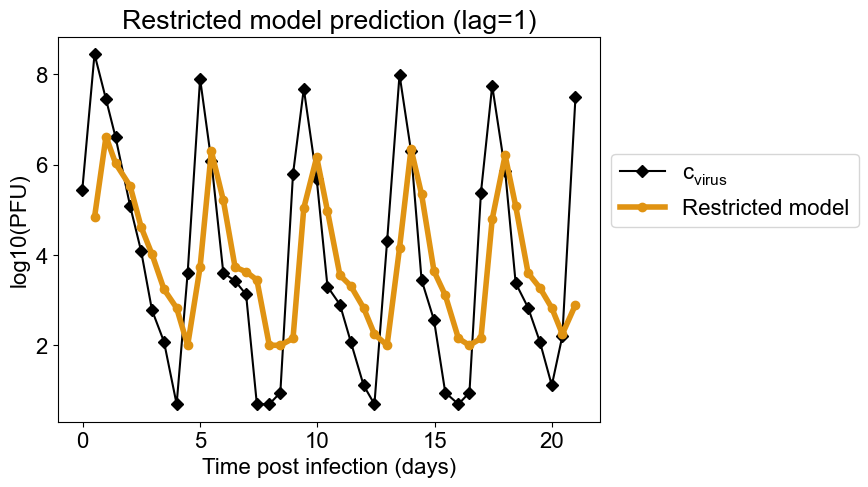

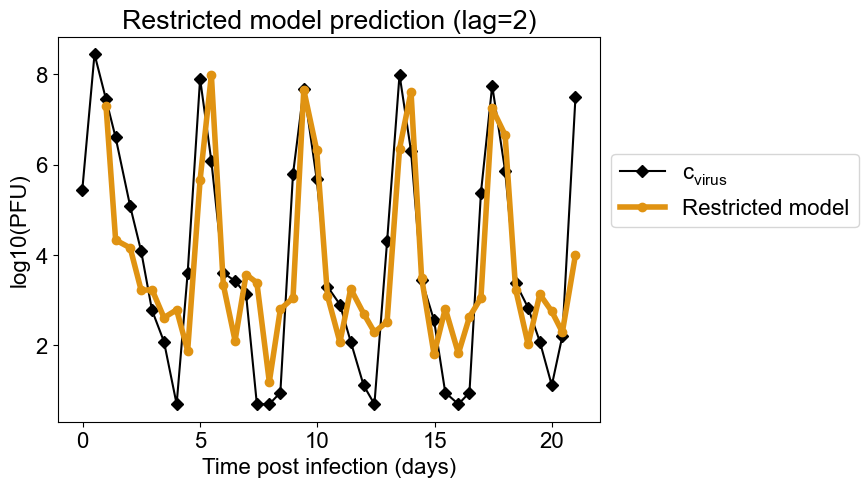

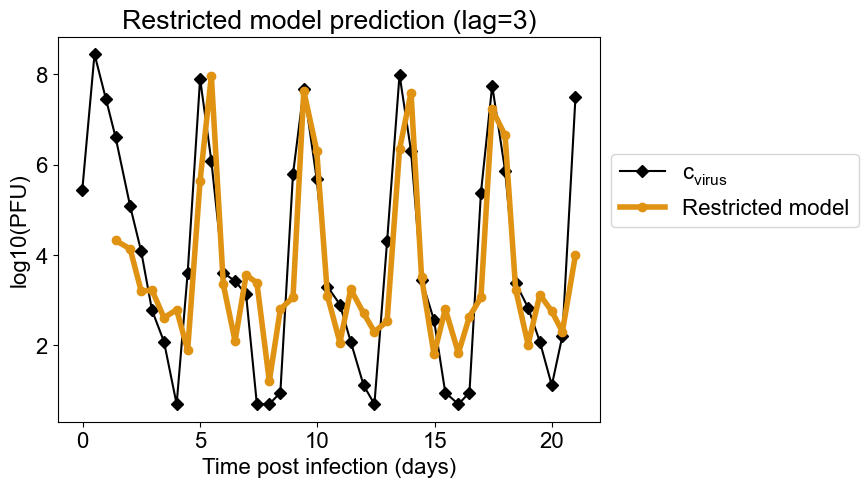

In [55]:
for fix_lag in range(1,max_fixed_lag):
  plot_restricted_only(cultivation_value_label='plaque_assay',
                        row=summary_df[fix_lag].sort_values(by='plaque_assay_ssr_chi2test').iloc[0],
                        figsize=(7, 5),
                        xlabel='Time post infection (days)',
                        ylabel='log10(PFU)',
                        yscale='linear',
                        gc_prediction_summary_df=gc_prediction_summary[fix_lag],
                        gc_test_results= test_results[fix_lag],
                        opt_lag=fix_lag)

Plotting PA_172_1938 (rank 1/1954)...
99.35398213757676


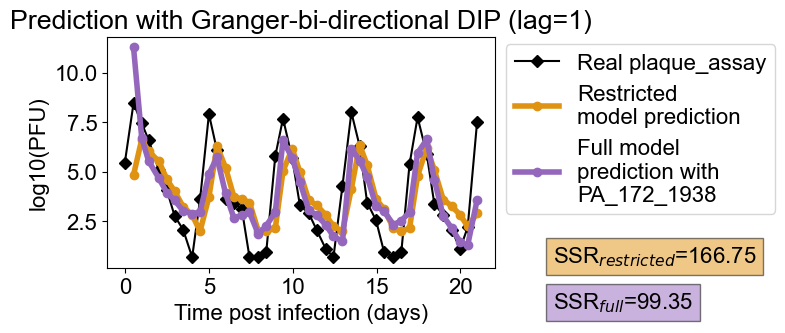

Plotting PB1_103_2173 (rank 2/1954)...
102.41722648916569


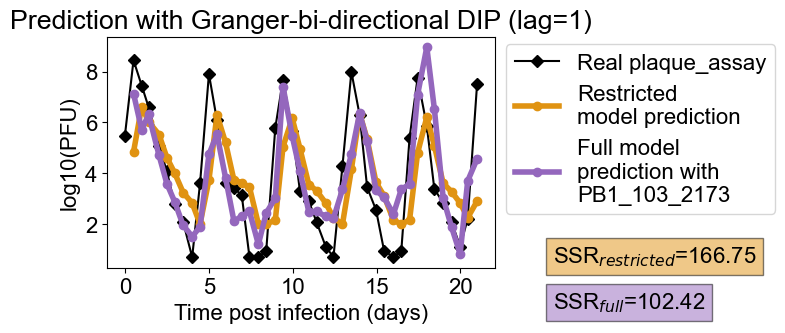

Plotting PA_316_1832 (rank 3/1954)...
105.09892366527922


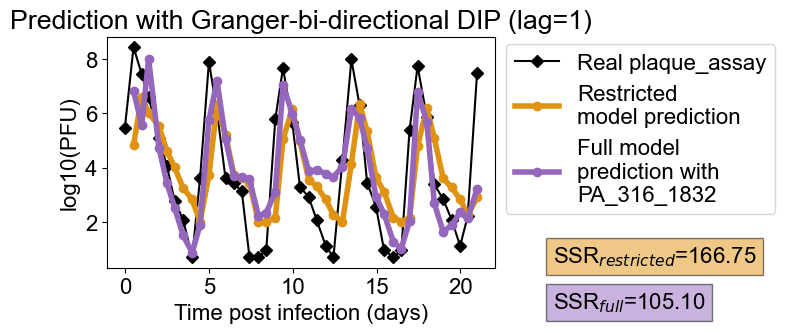

Plotting PB1_77_121 (rank 4/1954)...
106.71364421140464


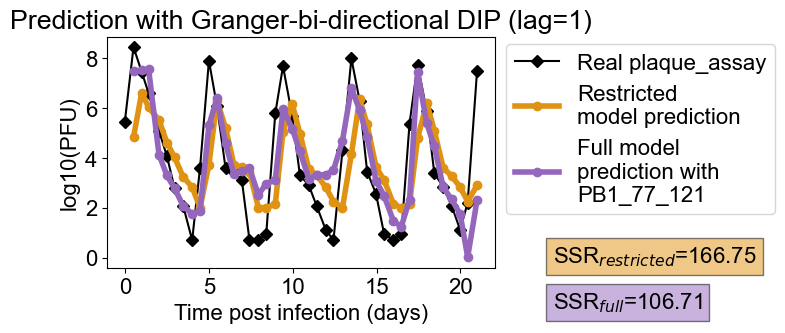

Plotting PA_295_372 (rank 5/1954)...
110.421375188854


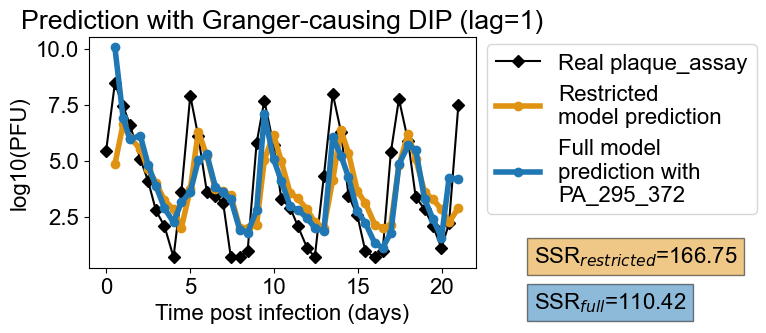

Plotting PB1_329_1996 (rank 6/1954)...
110.56384301032536


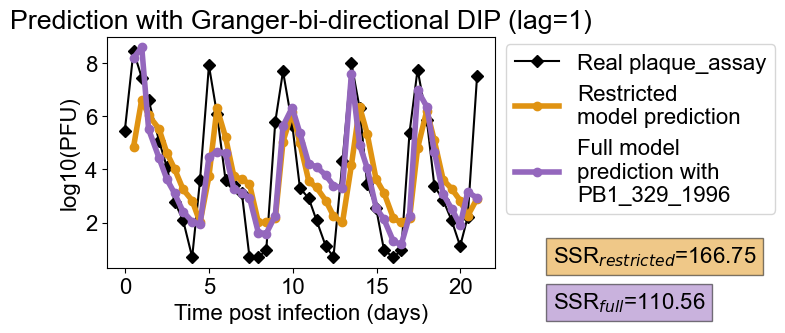

Plotting PA_179_1945 (rank 7/1954)...
113.33061478417518


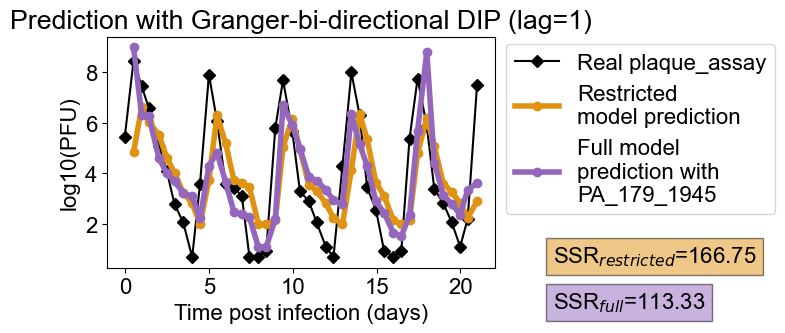

Plotting PA_138_172 (rank 8/1954)...
113.63883944767396


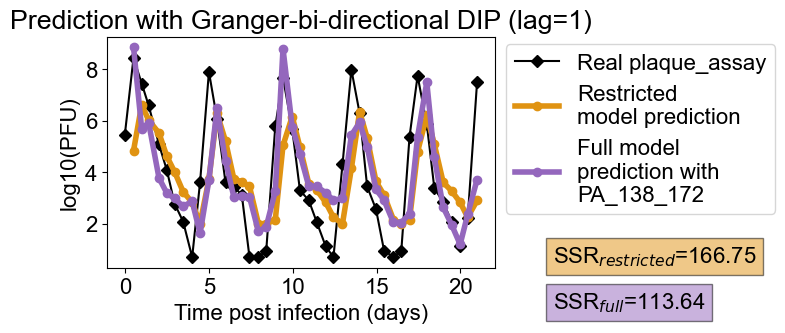

Plotting PA_164_1989 (rank 9/1954)...
114.6993982646876


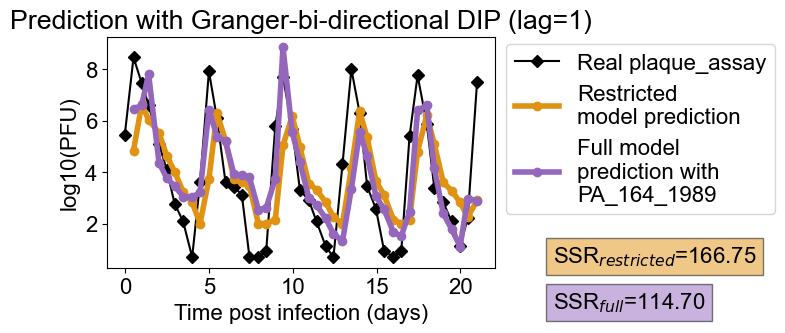

Plotting PA_297_1916 (rank 10/1954)...
115.7760783657205


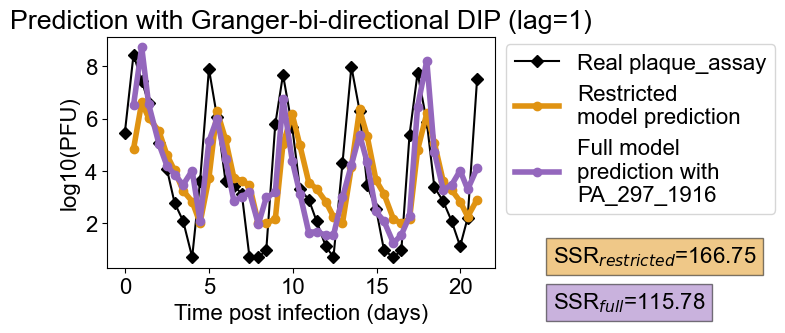

In [56]:
gc_prediction_summary_sorted = gc_prediction_summary[1].sort_values(by='ssr')

for idx, dvg in enumerate(gc_prediction_summary_sorted.key[:10]):
  print(f"Plotting {dvg} (rank {idx+1}/{len(gc_prediction_summary_sorted)})...")
  plot_single_candidate(cultivation_value_label ='plaque_assay',
                          dpis = stationary_ts_df.index.values,
                          row = summary_df[1][summary_df[1].key == dvg].iloc[0],
                          figsize = (5, 3),
                          xlabel = 'Time post infection (days)',
                          ylabel = 'log10(PFU)',
                          yscale = 'linear',
                          opt_lag = 1,
                          gc_prediction_summary_df = gc_prediction_summary[1],
                          gc_test_results= test_results[1],
                          log_long_data = stationary_ts_df)

## Plot all candidates of a group

Plotting lag 1...


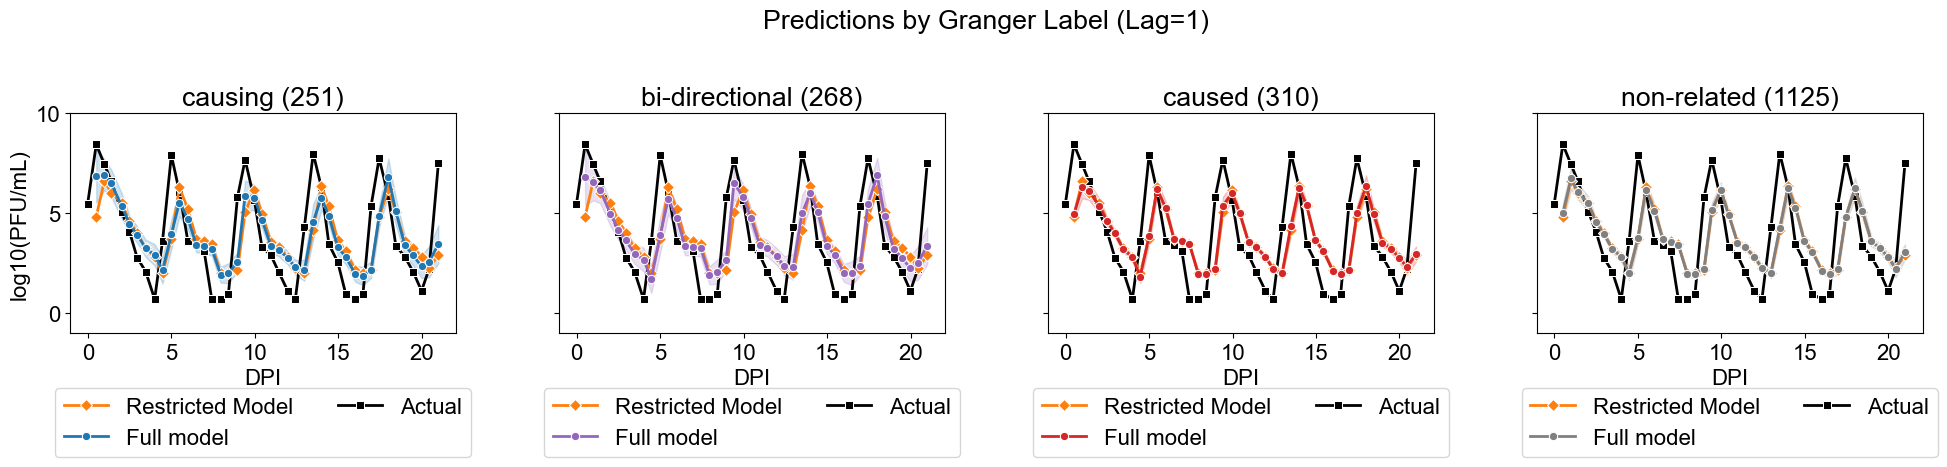

Plotting lag 2...


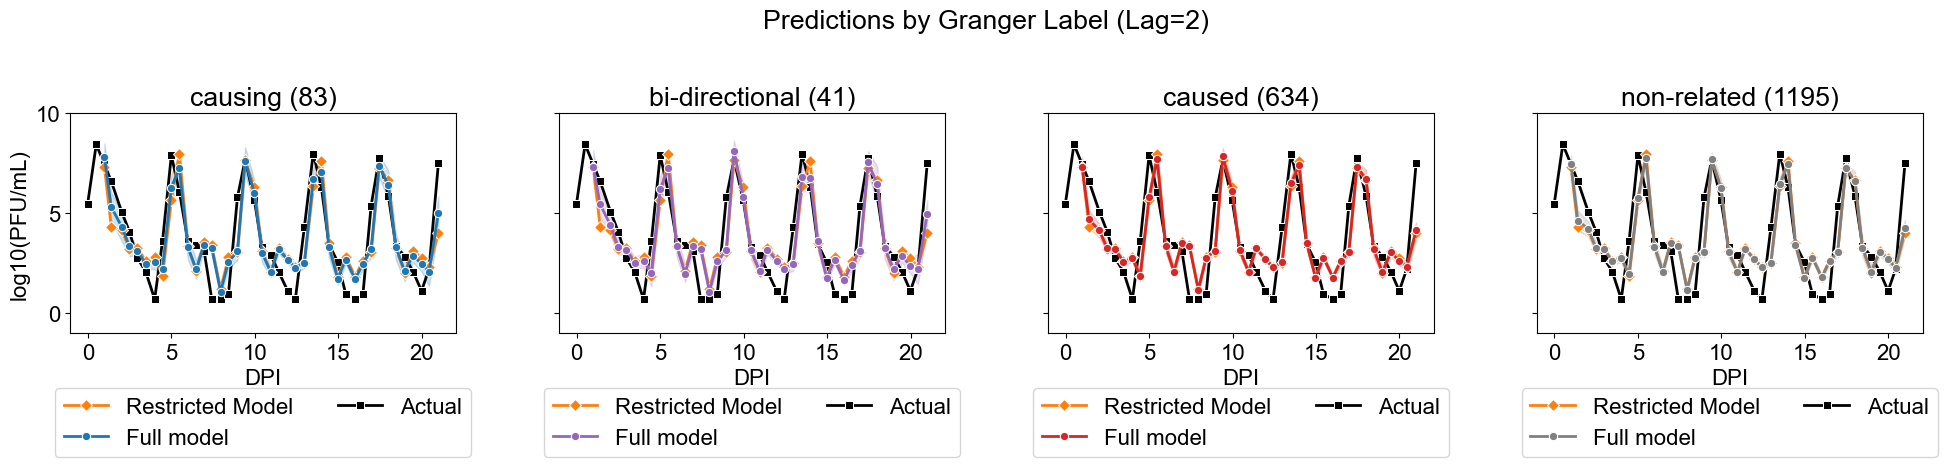

Plotting lag 3...


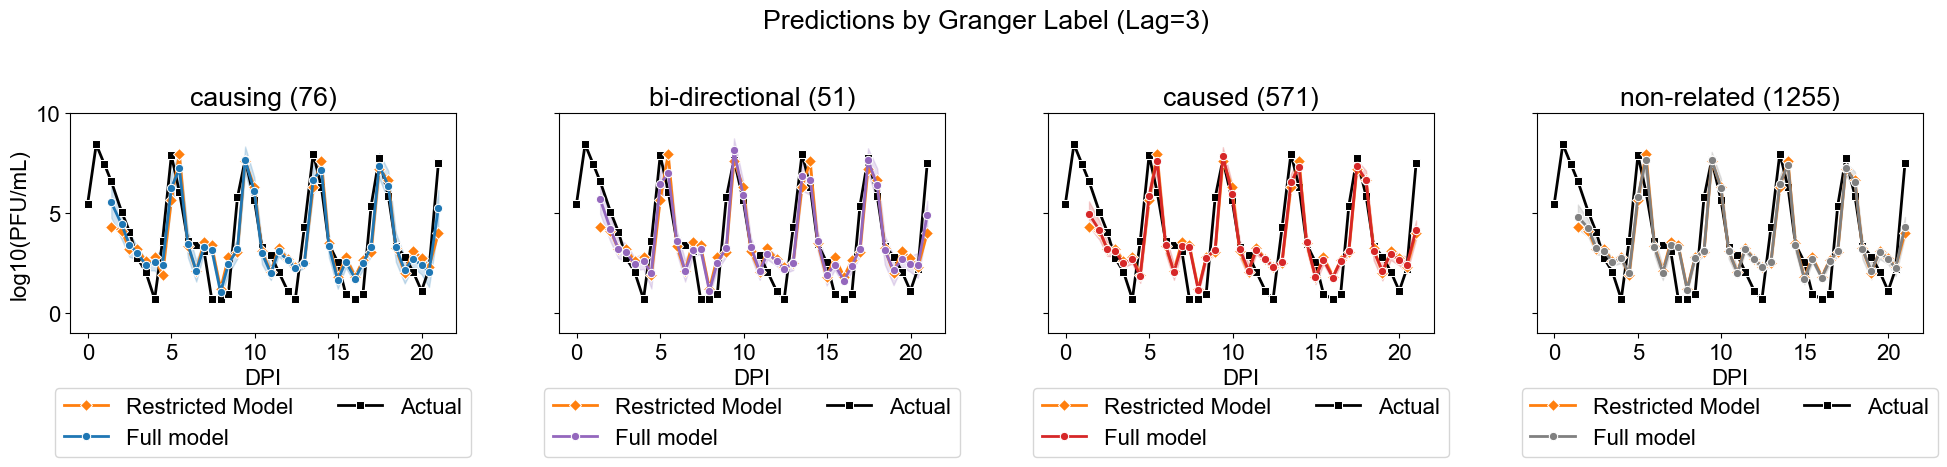

In [57]:
import seaborn as sns
def plot_predictions_by_label(
  gc_prediction_summary_df,
  gc_test_results,
  cultivation_value_label='plaque_assay',
  log_long_data=stationary_ts_df,
  label_order=['causing', 'bi-directional', 'caused', 'non-related', 'shuffled', 'bootstrapped'],
  figsize=(30, 4),
  output_prefix='',
  lag=1
):
  first_row = gc_prediction_summary_df.iloc[0]
  opt_lag = first_row['optimal_lag']
  restricted_pred = gc_test_results[(cultivation_value_label, first_row['key'])][opt_lag][1][0].predict()
  actual_value = log_long_data[cultivation_value_label]
  dpis = log_long_data.index.values
  
  fig, axs = plt.subplots(figsize=figsize, nrows=1, ncols=len(label_order), sharey=True)
  axs = axs.flatten()
  
  for label_idx, label in enumerate(label_order):
    label_df = gc_prediction_summary_df[gc_prediction_summary_df['granger_label'] == label]
    
    if label_df.empty:
      axs[label_idx].text(0.5, 0.5, 'No data', ha='center', va='center', 
                          transform=axs[label_idx].transAxes)
      axs[label_idx].set_title(f"{label} (0)")
      continue
    
    ax = axs[label_idx]
    
    # Aggregate predictions by DPI
    pred_by_dpi = {}
    for idx, row in label_df.iterrows():
      pred_dpis, pred_values = row['pred_data']
      for dpi, val in zip(pred_dpis, pred_values):
        pred_by_dpi.setdefault(dpi, []).append(val)
    
    pred_dpis_sorted = sorted(pred_by_dpi.keys())
    pred_means = [np.mean(pred_by_dpi[dpi]) for dpi in pred_dpis_sorted]
    pred_stds = [np.std(pred_by_dpi[dpi]) for dpi in pred_dpis_sorted]
    
    sns.lineplot(x=dpis, y=actual_value, marker='s', color='black', 
                 label='Actual', linewidth=2, ax=ax)
    sns.lineplot(x=dpis[opt_lag:], y=restricted_pred, marker='D', color='tab:orange', 
                 label='Restricted Model', linewidth=2, ax=ax)
    sns.lineplot(x=pred_dpis_sorted, y=pred_means, marker='o', 
                 color=granger_label_color_map.get(label, 'gray'),
                 label='Full model', linewidth=2, ax=ax)
    
    ax.fill_between(pred_dpis_sorted, np.array(pred_means) - np.array(pred_stds),
                    np.array(pred_means) + np.array(pred_stds),
                    color=granger_label_color_map.get(label, 'gray'), alpha=0.2)
    
    ax.set_title(f"{label} ({len(label_df)})")
    ax.set_ylabel('log10(PFU/mL)' if label_idx == 0 else '')
    ax.set_xlabel('DPI')
    ax.set_ylim(-1, 10)
    
    # Reorder legend
    handles, labels = ax.get_legend_handles_labels()
    order = [labels.index(name) for name in ['Restricted Model', 'Full model', 'Actual']]
    ax.legend([handles[i] for i in order], [labels[i] for i in order],
              loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)
  
  fig.suptitle(f'Predictions by Granger Label (Lag={lag})', y=1.01)
  plt.tight_layout()
  
  if output_prefix:
    fig.savefig(f"{output_prefix}/forecast_plots/predictions_by_label_lag{lag}.png", 
                dpi=300, bbox_inches='tight')
  plt.show()

for lag in range(1, max_fixed_lag):
  print(f"Plotting lag {lag}...")
  plot_predictions_by_label(
    gc_prediction_summary_df=gc_prediction_summary[lag],
    gc_test_results=test_results[lag],
    cultivation_value_label='plaque_assay',
    figsize=(20, 5),
    log_long_data=stationary_ts_df,
    label_order=['causing', 'bi-directional', 'caused', 'non-related'],
    lag=lag
  )

# Swarmplots

In [58]:
import seaborn as sns

## Helper Functions

In [59]:
def get_pval_symbol(pval):
    if pval < 0.0001:
        return '****'
    elif pval < 0.001:
        return '***'
    elif pval < 0.01:
        return '**'
    elif pval < 0.05:
        return '*'
    else:
        return ''

def better_percentage(group, val):
    n = len(group)
    perc = round(len(group[group < val]) / n * 100)
    return f'{perc}%\nbetter'

def get_main_color(granger_label):
    if granger_label == 'caused':
        return 'tab:red'
    elif granger_label == 'bi-directional':
        return 'tab:purple'
    elif granger_label == 'causing':
        return 'tab:blue'
    else:
        return 'grey'

def get_corrected_color(row, column='granger_score', invert=True):
    if row['granger_label'] == 'caused':
        base_color = plt.get_cmap('Reds')
    elif row['granger_label'] == 'bi-directional':
        base_color = plt.get_cmap('Purples')
    elif row['granger_label'] == 'causing':
        base_color = plt.get_cmap('Blues')
    else:
        base_color = plt.get_cmap('Greys')

    if invert == True:
        base_color = base_color.reversed()
        
    return base_color(row[column])

# Return a lighter shade based on the granger_score (the lower the score, the lighter the shade)
def get_corrected_color_v2(row, label_column, categories=[None,None,None], column='granger_score', invert=True):
    if row[label_column] == categories[0]:
        base_color = plt.get_cmap('Reds')
    elif row[label_column] == categories[1]:
        base_color = plt.get_cmap('Purples')
    elif row[label_column] == categories[2]:
        base_color = plt.get_cmap('Blues')
    else:
        base_color = plt.get_cmap('Greys')

    if invert == False:
        base_color = base_color.reversed()
        
    # Return a lighter shade based on the granger_score (the lower the score, the lighter the shade)
    return base_color(row[column])

# Function to calculate Cohen's d
def cohens_d(group1, group2):
    # Calculate means and standard deviations
    mean1, mean2 = np.mean(group1), np.mean(group2)
    std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)
    
    # Pooled standard deviation
    pooled_std = np.sqrt(((len(group1) - 1) * std1 ** 2 + (len(group2) - 1) * std2 ** 2) / (len(group1) + len(group2) - 2))
    
    # Cohen's d
    return (mean1 - mean2) / pooled_std

# Function to calculate Cliff's delta
def cliffs_delta(group1, group2):
    m, n = len(group1), len(group2)
    count = sum(1 if x > y else -1 if x < y else 0 for x in group1 for y in group2)
    return count / (m * n)

def test_statistical_difference(group1, group2, alpha=0.05):
    """
    Tests if two groups are statistically different from each other and returns effect size.

    Parameters:
    - group1, group2: The two groups to be compared.
    - alpha: Significance level for the tests.

    Returns:
    - A tuple containing:
    - p-value from the test
    - Effect size (Cohen's d for t-test, Cliff's delta for Mann-Whitney U test)
    - Test type ('t-test' or 'mann-whitney')
    """
    
    # Test for normality
    shapiro_test_group1 = shapiro(group1)
    shapiro_test_group2 = shapiro(group2)
    
    if shapiro_test_group1.pvalue > alpha and shapiro_test_group2.pvalue > alpha:
        # If both groups are normal, use T-test
        t_stat, t_pvalue = ttest_ind(list(group1), list(group2))
        
        # Calculate Cohen's d
        d = cohens_d(group1, group2)
        
        return t_pvalue, d, 't-test'
    else:
        # If either group is not normal, use Mann-Whitney U test
        mw_stat, mw_pvalue = mannwhitneyu(group1, group2)
        
        # Calculate Cliff's delta
        delta = cliffs_delta(group1, group2)
        
        return mw_pvalue, delta, 'mann-whitney'



## Functions

In [60]:
effect_size_dct = {'mann-whitney': 'Cliff\'s delta', 't-test': 'Cohen\'s d'}

def make_performance_swarmplot(dip_forecast_summary,
                                ref_performance_dct,
                                performance_metric='mape',
                                forecasted_value = 'pfu',
                                title = 'Granger-related DI vRNAs predictive power over PFU\n',
                                ylabel='Mean Absolute Percentage Error (MAPE)',
                                dot_color_ref = 'diff_level_norm',
                                inverted_colors = True, # the higher the value, the darker the color
                                upper_border = -10,
                                ymax = None,
                                ymin = 0,
                                yscale = 'linear',
                                p_val_pos = 0,
                                figsize=(8, 4),
                                better_perc = False,
                                markersize=18,
                                linewidth=4,
                                dotsize=5,
                                included_dvgs = None
                                ): 
    dip_forecast_summary['corrected_color'] = dip_forecast_summary.apply(get_corrected_color, args=(dot_color_ref, inverted_colors), axis=1)
    
    if included_dvgs is not None:
        dip_forecast_summary = dip_forecast_summary[dip_forecast_summary.key.isin(included_dvgs)]
        
    # Create the swarm plot
    fig, axs = plt.subplots(nrows=1, figsize=figsize)
    ax = axs
    ax = sns.swarmplot(x='granger_label', 
                        y=performance_metric, 
                        hue='key',
                        data=dip_forecast_summary, 
                        order = ['causing', 'bi-directional', 'caused', 'non-related'],
                        palette=dip_forecast_summary['corrected_color'].tolist(),
                        size=dotsize, ax=ax, legend=False, linewidth=0.2
    )
    # Set title and other plot parameters
    ax.set_title(title, pad=15)
    ax.set_xlabel('Granger causality label', labelpad=10)

    ax.set_ylabel(ylabel)
    xmin, xmax = ax.get_xlim()
    ax.hlines(y=ref_performance_dct[performance_metric.upper()], xmin=xmin, xmax=xmax, label='restricted model performance', color='#e09312', linewidth=linewidth, zorder=10)
    ax.legend(loc='lower right')
    if ymax is None:
        ymax = ref_performance_dct[performance_metric.upper()]*3
    ax.set_ylim(ymin, ymax)
    ax.set_yscale(yscale)
    #ax.invert_yaxis()
    ax.tick_params(top=False, labeltop=False, bottom=True, labelbottom=True)

    xs, xticklabels = ax.get_xticks(), ax.get_xticklabels()

    # Loop through the x-axis categories and plot the medians as markers
    for x, xticklabel in zip(xs, xticklabels):
        label = xticklabel.get_text()
        
        # Calculate median
        median_value = dip_forecast_summary[dip_forecast_summary.granger_label == label][performance_metric].median()
        
        # Plot the median as a horizontal marker (-)
        ax.plot(x, median_value, marker='+', color='black', markersize=markersize, zorder=11, label=f'{label} Median')
        
        ax.text(x, p_val_pos, f'n={len(dip_forecast_summary[dip_forecast_summary.granger_label == label])}', ha='center', va='bottom', color='black', zorder=10)

        if better_perc:
            ax.text(x, upper_border, 
                better_percentage(dip_forecast_summary[dip_forecast_summary.granger_label == label][performance_metric], 
                                        ref_performance_dct[performance_metric.upper()]), 
                    ha='center', va='bottom', color='black', zorder=10)
    
    fig.tight_layout()
    # fig.savefig(f'data/outputs/granger_causality/{performance_metric}_swarmplot_{forecasted_value}.pdf', bbox_inches='tight')
    return fig, ax

In [61]:
import seaborn as sns

## all 

In [62]:
plt.rcParams.update({'font.size': 28})
! mkdir -p {output_prefix}/plots


In [63]:
gc_prediction_summary[1]

,key,granger_label,optimal_lag,diff_level,ssr_chi2test_pval,significant_pvals,mape,mae,rmse,nrsme,...,relative_wmae,relative_wmape,relative_dtw,relative_mse,dtw_aligned_mape,ssr,weighted_ssr,pred_data,norm_ssr_chi2test_pval,group_norm_ssr_chi2test_pval
0,M_132_939,bi-directional,1,0.0,0.003818,3,0.701922,1.424700,1.819526,0.467563,...,0.877090,0.925886,1.166170,0.833853,50.530283,139.048350,0.046398,"([0.5, 0.99, 1.4, 2.02, 2.49, 2.95, 3.46, 4.0,...",0.038176,0.077235
1,NA_175_1066,bi-directional,1,0.0,0.000652,3,0.663457,1.338845,1.763460,0.453156,...,0.798496,0.835623,1.070534,0.783257,37.796057,130.611295,0.043582,"([0.5, 0.99, 1.4, 2.02, 2.49, 2.95, 3.46, 4.0,...",0.006517,0.013184
2,PA_120_147,bi-directional,1,0.0,0.006958,3,0.709358,1.528427,1.839442,0.472681,...,0.880705,0.938715,0.955512,0.852206,41.496079,142.108892,0.047419,"([0.5, 0.99, 1.4, 2.02, 2.49, 2.95, 3.46, 4.0,...",0.069578,0.140766
3,PA_120_164,bi-directional,1,0.0,0.000034,3,0.665625,1.321876,1.678225,0.431253,...,0.747994,0.916627,1.038777,0.709370,37.443695,118.290423,0.039471,"([0.5, 0.99, 1.4, 2.02, 2.49, 2.95, 3.46, 4.0,...",0.000335,0.000678
4,PA_120_172,causing,1,0.0,0.026854,3,0.726636,1.463233,1.885606,0.484544,...,0.890329,0.935433,1.060709,0.895519,45.544124,149.331453,0.049829,"([0.5, 0.99, 1.4, 2.02, 2.49, 2.95, 3.46, 4.0,...",0.268539,0.538244
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1949,PB2_193_2158,non-related,1,2.0,0.320097,0,0.767354,1.643495,1.969527,0.506109,...,0.988431,1.007701,0.918384,0.977004,35.295855,162.919485,0.054363,"([0.5, 0.99, 1.4, 2.02, 2.49, 2.95, 3.46, 4.0,...",3.200973,0.320630
1950,PB2_2131_2156,non-related,1,2.0,0.827015,0,0.751899,1.608493,1.991438,0.511740,...,0.994648,0.998866,0.996448,0.998864,39.054994,166.564709,0.055579,"([0.5, 0.99, 1.4, 2.02, 2.49, 2.95, 3.46, 4.0,...",8.270154,0.828390
1951,PB2_2171_2196,non-related,1,2.0,0.756084,0,0.754906,1.633314,1.990285,0.511443,...,1.003640,1.000685,0.985790,0.997708,38.529720,166.371884,0.055515,"([0.5, 0.99, 1.4, 2.02, 2.49, 2.95, 3.46, 4.0,...",7.560842,0.757341
1952,PB1_170_2194,non-related,1,3.0,0.660085,0,0.761256,1.623763,1.987998,0.510856,...,0.998286,1.012335,1.000339,0.995416,39.165551,165.989678,0.055387,"([0.5, 0.99, 1.4, 2.02, 2.49, 2.95, 3.46, 4.0,...",6.600853,0.661183


In [64]:
plt.rcParams.update({'font.size': 28})
for fixlag in range(1, max_fixed_lag):
  print(f'Creating performance swarmplot for lag {fixlag}...')
  fig, ax = make_performance_swarmplot(
      dip_forecast_summary=gc_prediction_summary[fixlag],
      ref_performance_dct=ref_ols_performance_dct[fixlag],
      performance_metric='ssr',
      forecasted_value = 'plaque_assay',
      title = f'Granger-related DVGs predictive power over PFU (lag={fixlag})',
      ylabel='SSR',
      dot_color_ref = 'group_norm_ssr_chi2test_pval',
      inverted_colors=True,
      upper_border=-0.05,
      ymax=ref_ols_performance_dct[fixlag]['SSR']*2,
      ymin=-10,
      p_val_pos=ref_ols_performance_dct[fixlag]['SSR']*1.5,
      figsize=(18,7),
      dotsize=8,
      linewidth=5
  )
  fig.savefig(f'{output_prefix}/plots/ssr_swarmplot_lag{fixlag}.png')

Creating performance swarmplot for lag 1...
Creating performance swarmplot for lag 2...
Creating performance swarmplot for lag 3...
Error in callback <function _draw_all_if_interactive at 0x7f68fc3b6820> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7f6914441af0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
# non_zero_threshold = 0.7
# threshold = 0.7
# ts_data_filtered = lin_interpolated_ts_df.loc[:, (lin_interpolated_ts_df != 0).mean() >= threshold]
# selected_dips = ts_data_filtered.columns[1:].tolist()


# plt.rcParams.update({'font.size': 28})
# for fixlag in range(1, max_fixed_lag):
#   print(f'Creating performance swarmplot for lag {fixlag}...')
#   fig, ax = make_performance_swarmplot(
#       dip_forecast_summary=gc_prediction_summary[fixlag],
#       ref_performance_dct=ref_ols_performance_dct[fixlag],
#       performance_metric='ssr',
#       forecasted_value = 'plaque_assay',
#       title = f'Granger-related DVGs predictive power over PFU (lag={fixlag})',
#       ylabel='SSR',
#       dot_color_ref = 'group_norm_ssr_chi2test_pval',
#       inverted_colors=True,
#       upper_border=-0.05,
#       ymax=ref_ols_performance_dct[fixlag]['SSR']*2,
#       ymin=-10,
#       p_val_pos=ref_ols_performance_dct[fixlag]['SSR']*1.5,
#       figsize=(18,7),
#       dotsize=8,
#       linewidth=5,
#   )
#   #fig.savefig(f'{output_prefix}/plots/ssr_swarmplot_lag{fixlag}.png')

## corrected

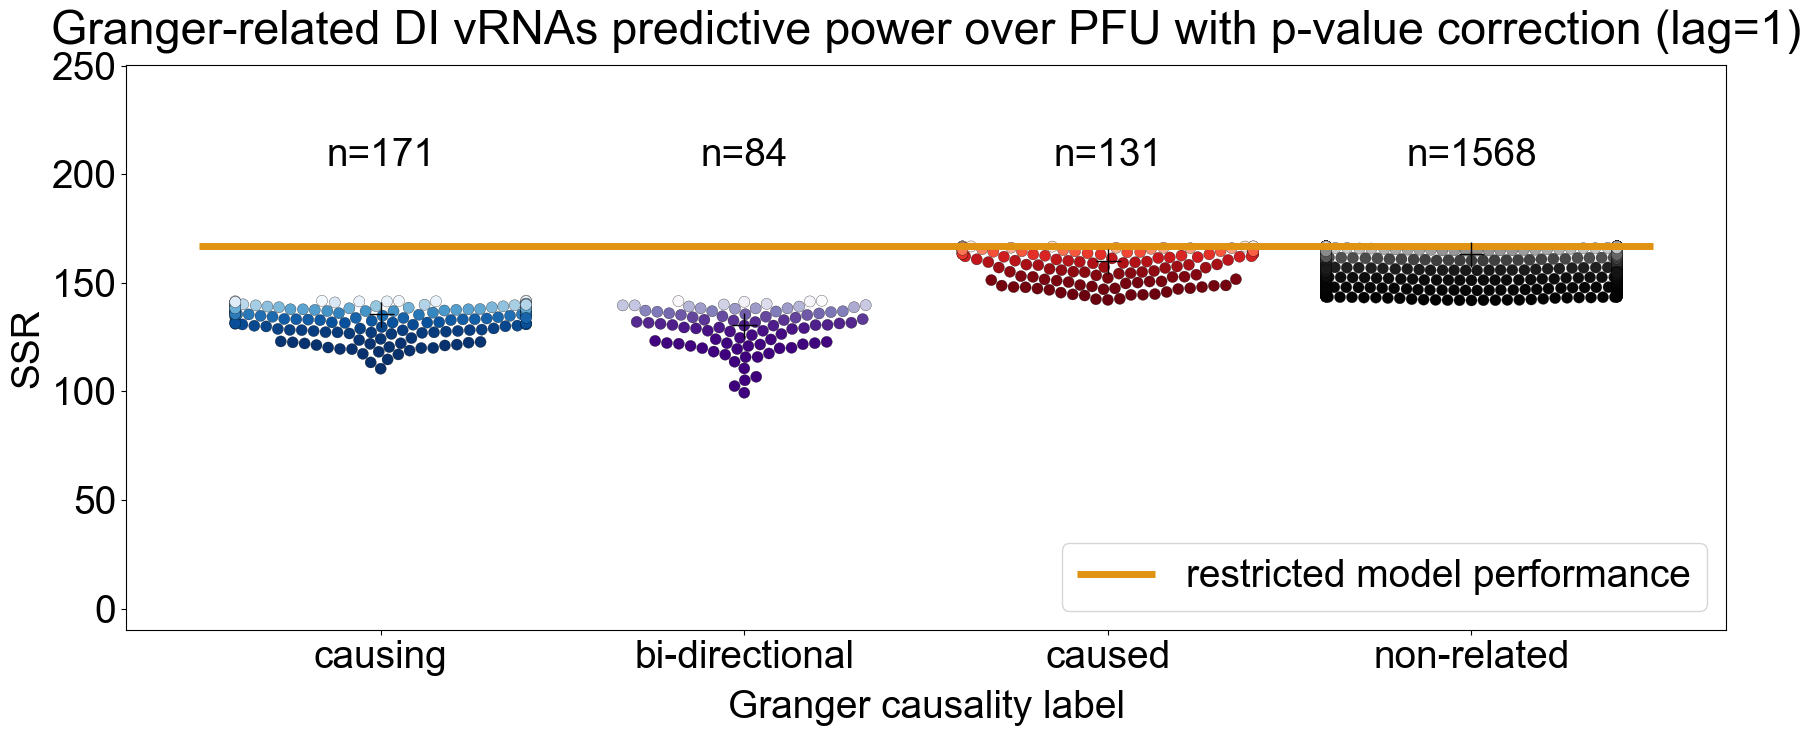

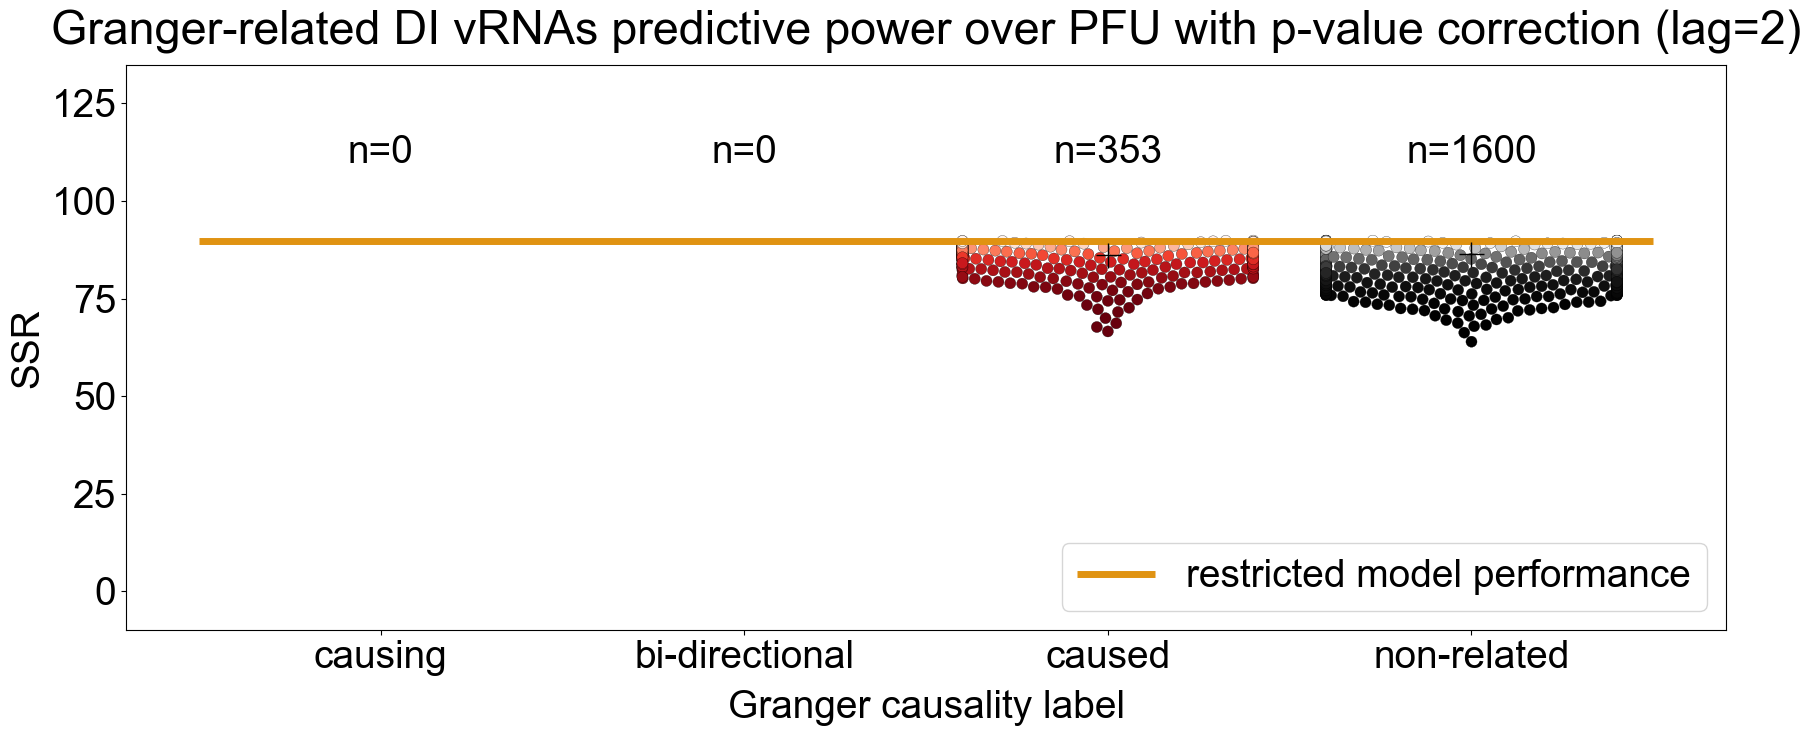

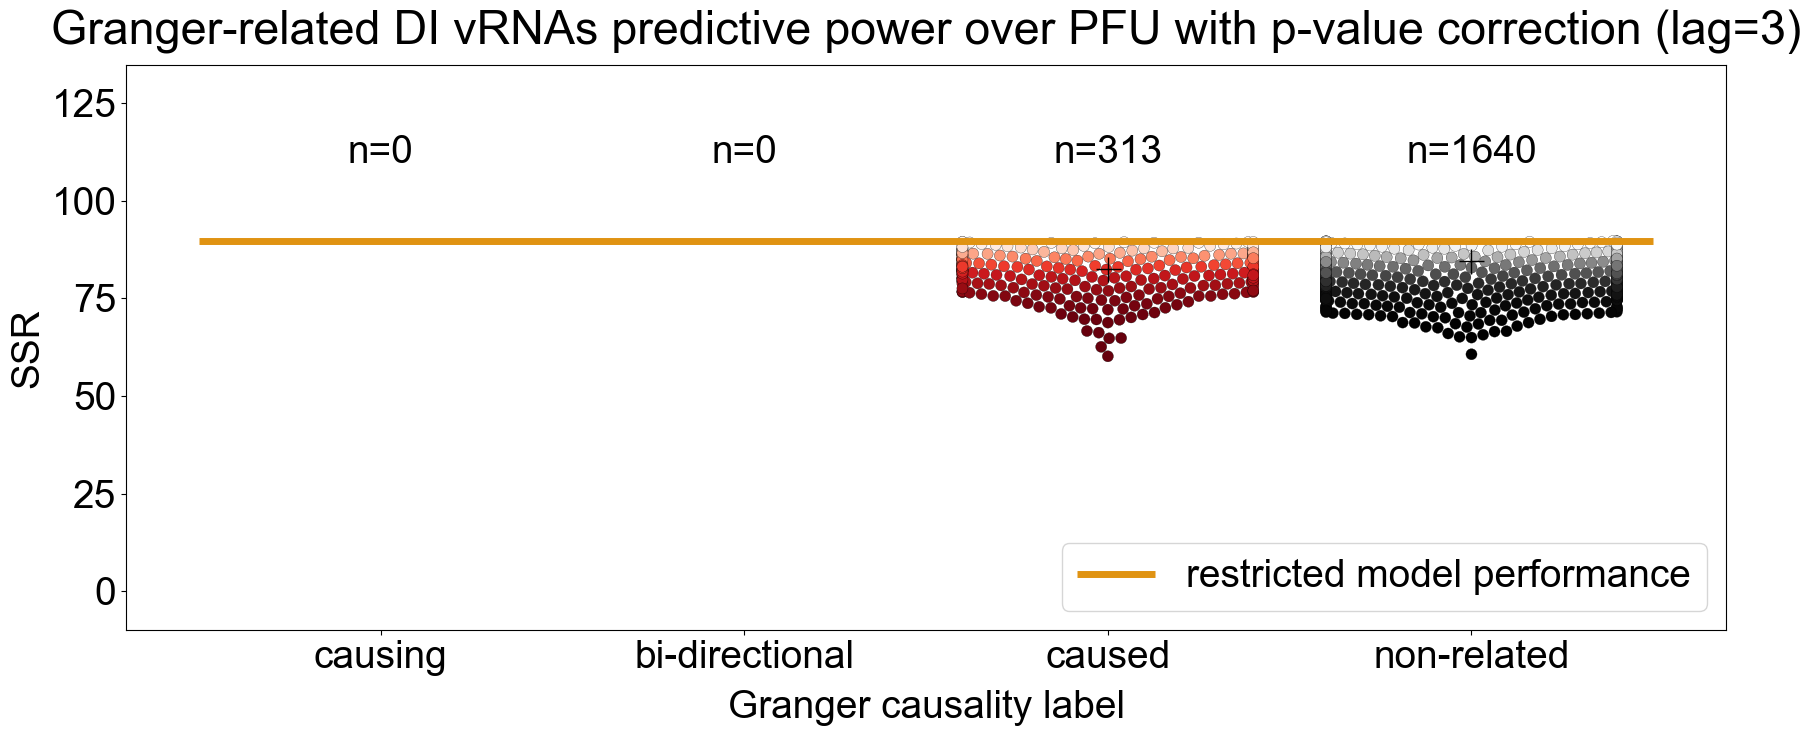

In [ ]:
plt.rcParams.update({'font.size': 28})
for fix_lag in range(1,max_fixed_lag):
  fig, ax = make_performance_swarmplot(gc_prediction_summary_corrected[fix_lag],
                              ref_ols_performance_corrected_dct[fix_lag],
                              performance_metric='ssr',
                              forecasted_value = 'plaque_assay',
                              title = f'Granger-related DI vRNAs predictive power over PFU with p-value correction (lag={fix_lag})',
                              ylabel='SSR',
                              dot_color_ref = 'group_norm_ssr_chi2test_pval',
                              inverted_colors=True,
                              upper_border=-0.05,
                              ymax=ref_ols_performance_corrected_dct[fix_lag]['SSR']*1.5,
                              ymin=-10,
                              p_val_pos=ref_ols_performance_corrected_dct[fix_lag]['SSR']*1.2,
                              figsize=(18,8),
                              dotsize=8,
                              linewidth=5
                              )
  fig.savefig(f'{output_prefix}/plots/ssr_swarmplot_corrected_lag{fix_lag}.png')
  fig.show()

# group sizes with increasing lag

## all

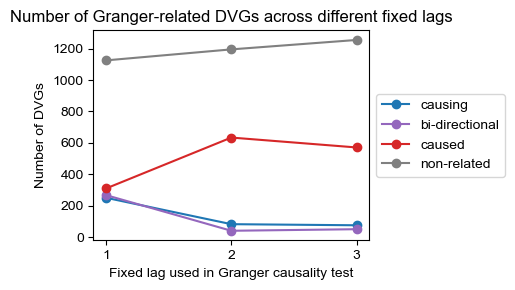

In [ ]:
plt.rcParams.update({'font.size': 10})
fig, ax = plt.subplots(figsize=(5, 3))

for label, color in zip(['causing', 'bi-directional', 'caused', 'non-related'],
                        ['tab:blue', 'tab:purple', 'tab:red', 'gray']):
  group_sizes = []    
  for fixlag in range(1, max_fixed_lag):
    subset = gc_prediction_summary[fixlag][gc_prediction_summary[fixlag]['granger_label'] == label]
    group_sizes.append(len(subset))
  ax.plot(range(1, max_fixed_lag), group_sizes, marker='o', label=label, color=color)
ax.set_xlabel('Fixed lag used in Granger causality test')
ax.set_ylabel('Number of DVGs')
ax.set_title('Number of Granger-related DVGs across different fixed lags')
# Add legend next to the plot
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_xticks(range(1, max_fixed_lag))
plt.tight_layout()

## corrected

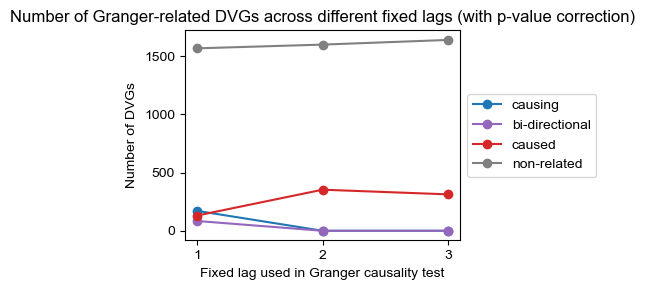

In [ ]:
plt.rcParams.update({'font.size': 10})
fig, ax = plt.subplots(figsize=(5, 3))

for label, color in zip(['causing', 'bi-directional', 'caused', 'non-related'],
                        ['tab:blue', 'tab:purple', 'tab:red', 'gray']):
  group_sizes = []    
  for fixlag in range(1, max_fixed_lag):
    subset = gc_prediction_summary_corrected[fixlag][gc_prediction_summary_corrected[fixlag]['granger_label'] == label]
    group_sizes.append(len(subset))
  ax.plot(range(1, max_fixed_lag), group_sizes, marker='o', label=label, color=color)
ax.set_xlabel('Fixed lag used in Granger causality test')
ax.set_ylabel('Number of DVGs')
ax.set_title('Number of Granger-related DVGs across different fixed lags (with p-value correction)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_xticks(range(1, max_fixed_lag))
plt.tight_layout()

## all vs corrected

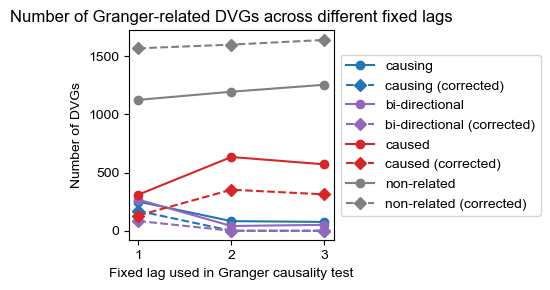

In [ ]:
plt.rcParams.update({'font.size': 10})
fig, ax = plt.subplots(figsize=(5, 3))

for label, color in zip(['causing', 'bi-directional', 'caused', 'non-related'],
                        ['tab:blue', 'tab:purple', 'tab:red', 'gray']):
  group_sizes = []
  group_sizes_corrected = [] 
  for fixlag in range(1, max_fixed_lag):
    subset = gc_prediction_summary[fixlag][gc_prediction_summary[fixlag]['granger_label'] == label]
    group_sizes.append(len(subset))
    
    subset_corrected = gc_prediction_summary_corrected[fixlag][gc_prediction_summary_corrected[fixlag]['granger_label'] == label]
    group_sizes_corrected.append(len(subset_corrected))
  ax.plot(range(1, max_fixed_lag), group_sizes, marker='o', label=label, color=color, linestyle='solid')
  ax.plot(range(1, max_fixed_lag), group_sizes_corrected, marker='D', label=f'{label} (corrected)', color=color, linestyle='dashed')
ax.set_xlabel('Fixed lag used in Granger causality test')
ax.set_ylabel('Number of DVGs')
ax.set_title('Number of Granger-related DVGs across different fixed lags')
# Add legend next to the plot
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_xticks(range(1, max_fixed_lag))
plt.tight_layout()

# SSR with increasing lag

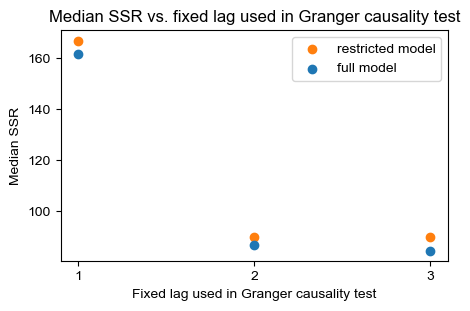

In [ ]:
plt.rcParams.update({'font.size': 10})
fig, ax = plt.subplots(figsize=(5, 3))
for fixlag in range(1, max_fixed_lag):
    ax.scatter(fixlag,
              ref_ols_performance_dct[fixlag]['SSR'],
              color='tab:orange',
              label='restricted model' if fixlag == 1 else "")
ax.set_xlabel('Fixed lag used in Granger causality test')
ax.set_ylabel('Restricted model SSR')
ax.set_xticks(range(1, max_fixed_lag))
ax.set_title('Restricted model SSR vs. fixed lag used in Granger causality test')

mean_ssr_full_model = []
for fixlag in range(1, max_fixed_lag):
    mean_ssr_full_model.append(gc_prediction_summary[fixlag]['ssr'].median())
    ax.scatter(fixlag,
              gc_prediction_summary[fixlag]['ssr'].median(),
              color='tab:blue',
              label='full model' if fixlag==1 else "")
ax.set_xlabel('Fixed lag used in Granger causality test')
ax.set_ylabel('Median SSR')
ax.set_xticks(range(1, max_fixed_lag))
ax.set_title('Median SSR vs. fixed lag used in Granger causality test')
ax.legend(loc='upper right')
plt.show()

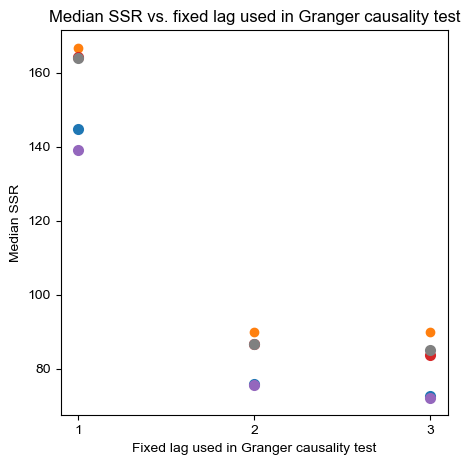

In [ ]:
plt.rcParams.update({'font.size': 10})
fig, ax = plt.subplots(figsize=(5, 5))
for fixlag in range(1, max_fixed_lag):
    ax.scatter(fixlag,
              ref_ols_performance_dct[fixlag]['SSR'],
              color='tab:orange',
              label='restricted model' if fixlag == 1 else "")
ax.set_xlabel('Fixed lag used in Granger causality test')
ax.set_ylabel('Restricted model SSR')
ax.set_xticks(range(1, max_fixed_lag))
ax.set_title('Restricted model SSR vs. fixed lag used in Granger causality test')

mean_ssr_full_model = []


for label, color in zip(['causing', 'bi-directional', 'caused', 'non-related'],
                        ['tab:blue', 'tab:purple', 'tab:red', 'gray']):
  mean_ssr_full_model = []    
  for fixlag in range(1, max_fixed_lag):
    subset = gc_prediction_summary[fixlag][gc_prediction_summary[fixlag]['granger_label'] == label]
    mean_ssr_full_model.append(subset['ssr'].median())
    ax.scatter(fixlag,
              subset['ssr'].median(),
              color=color,
              label=label if fixlag==1 else "",
              linewidth=2)
ax.set_xlabel('Fixed lag used in Granger causality test')
ax.set_ylabel('Median SSR')
ax.set_xticks(range(1, max_fixed_lag))
ax.set_title('Median SSR vs. fixed lag used in Granger causality test')
plt.show()

## corrected

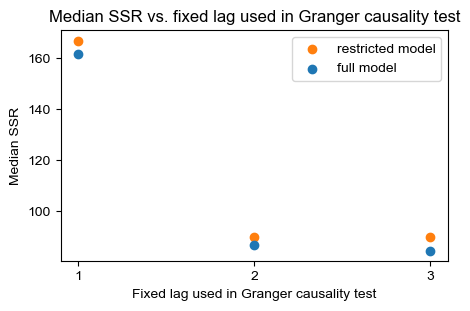

In [ ]:
plt.rcParams.update({'font.size': 10})
fig, ax = plt.subplots(figsize=(5, 3))
for fixlag in range(1, max_fixed_lag):
    ax.scatter(fixlag,
              ref_ols_performance_corrected_dct[fixlag]['SSR'],
              color='tab:orange',
              label='restricted model' if fixlag == 1 else "")
ax.set_xlabel('Fixed lag used in Granger causality test')
ax.set_ylabel('Restricted model SSR')
ax.set_xticks(range(1, max_fixed_lag))
ax.set_title('Restricted model SSR vs. fixed lag used in Granger causality test')

mean_ssr_full_model = []
for fixlag in range(1, max_fixed_lag):
    mean_ssr_full_model.append(gc_prediction_summary_corrected[fixlag]['ssr'].median())
    ax.scatter(fixlag,
              gc_prediction_summary_corrected[fixlag]['ssr'].median(),
              color='tab:blue',
              label='full model' if fixlag==1 else "")
ax.set_xlabel('Fixed lag used in Granger causality test')
ax.set_ylabel('Median SSR')
ax.set_xticks(range(1, max_fixed_lag))
ax.set_title('Median SSR vs. fixed lag used in Granger causality test')
ax.legend(loc='upper right')
plt.show()

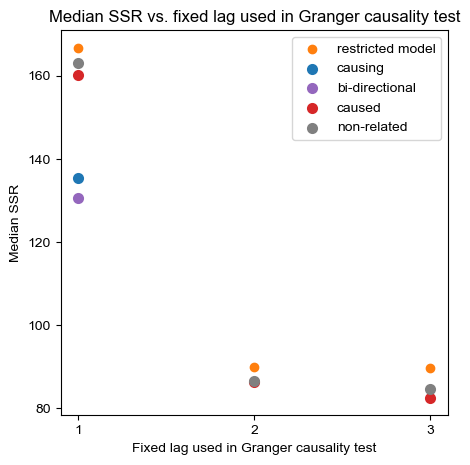

In [ ]:
plt.rcParams.update({'font.size': 10})
fig, ax = plt.subplots(figsize=(5, 5))
for fixlag in range(1, max_fixed_lag):
    ax.scatter(fixlag,
              ref_ols_performance_corrected_dct[fixlag]['SSR'],
              color='tab:orange',
              label='restricted model' if fixlag == 1 else "")
ax.set_xlabel('Fixed lag used in Granger causality test')
ax.set_ylabel('Restricted model SSR')
ax.set_xticks(range(1, max_fixed_lag))
ax.set_title('Restricted model SSR vs. fixed lag used in Granger causality test')

mean_ssr_full_model = []


for label, color in zip(['causing', 'bi-directional', 'caused', 'non-related'],
                        ['tab:blue', 'tab:purple', 'tab:red', 'gray']):
  mean_ssr_full_model = []    
  for fixlag in range(1, max_fixed_lag):
    subset = gc_prediction_summary_corrected[fixlag][gc_prediction_summary_corrected[fixlag]['granger_label'] == label]
    mean_ssr_full_model.append(subset['ssr'].median())
    ax.scatter(fixlag,
              subset['ssr'].median(),
              color=color,
              label=label if fixlag==1 else "",
              linewidth=2)
ax.set_xlabel('Fixed lag used in Granger causality test')
ax.set_ylabel('Median SSR')
ax.set_xticks(range(1, max_fixed_lag))
ax.set_title('Median SSR vs. fixed lag used in Granger causality test')
ax.legend(loc='upper right')
plt.show()

# Granger causality test only on non-zero parts of the time series for PB2_269_2202

In [ ]:
gc_prediction_summary[1][gc_prediction_summary[1]['key'] == 'PB2_269_2202']

,key,granger_label,optimal_lag,diff_level,ssr_chi2test_pval,significant_pvals,mape,mae,rmse,nrsme,...,relative_wmape,relative_dtw,relative_mse,dtw_aligned_mape,ssr,weighted_ssr,pred_data,norm_ssr_chi2test_pval,group_norm_ssr_chi2test_pval,corrected_color
1875,PB2_269_2202,non-related,1,1.0,0.959041,0,0.753569,1.620946,1.992508,0.512015,...,1.001393,0.998281,0.999937,39.3991,166.743629,0.055639,"([0.5, 0.99, 1.4, 2.02, 2.49, 2.95, 3.46, 4.0,...",9.590408,0.960635,"(0.9815455594002307, 0.9815455594002307, 0.981..."


In [ ]:
# index at which the first value > 15 appears
first_non_zero_timepoint = ts_df['PB2_269_2202'].gt(15).idxmax()
print(f"First time point with value > 15: {first_non_zero_timepoint}")

First time point with value > 15: 13.5


In [ ]:
denovo_ts_df = log_interpolated_ts_df[13.5:][['plaque_assay', 'PB2_269_2202']].copy()
denovo_ts_df

,plaque_assay,PB2_269_2202
13.50,7.991226,1.869232
13.99,6.301030,1.808886
14.44,3.447313,1.738781
14.97,2.557507,1.655138
15.45,0.954243,1.551450
16.01,0.698970,1.414973
16.48,0.954243,1.648360
16.97,5.380213,1.799341
17.45,7.748188,2.290035
18.00,5.869232,2.536558


In [ ]:
stationary_denovo_ts_df = make_stationary(denovo_ts_df, max_diff=10, autolag='AIC', max_lag=None).df_stationary.fillna(0)
stationary_denovo_ts_df

,plaque_assay,PB2_269_2202
13.50,7.991226,0.000000
13.99,6.301030,-0.060346
14.44,3.447313,-0.070105
14.97,2.557507,-0.083642
15.45,0.954243,-0.103688
16.01,0.698970,-0.136477
16.48,0.954243,0.233387
16.97,5.380213,0.150981
17.45,7.748188,0.490694
18.00,5.869232,0.246524


In [ ]:
stationary_denovo_ts_df

,plaque_assay,PB2_269_2202
13.50,7.991226,0.000000
13.99,6.301030,-0.060346
14.44,3.447313,-0.070105
14.97,2.557507,-0.083642
15.45,0.954243,-0.103688
16.01,0.698970,-0.136477
16.48,0.954243,0.233387
16.97,5.380213,0.150981
17.45,7.748188,0.490694
18.00,5.869232,0.246524


In [ ]:
denovo_gc_test_results = grangercausalitytests(stationary_denovo_ts_df[['plaque_assay', 'PB2_269_2202']], maxlag=1, verbose=True)
denovo_gc_test_results_rv = grangercausalitytests(stationary_denovo_ts_df[['PB2_269_2202', 'plaque_assay']], maxlag=1, verbose=True)
denovo_full_pred = denovo_gc_test_results[1][1][1].predict()
denovo_restr_pred = denovo_gc_test_results[1][1][0].predict()
SSR_full = denovo_gc_test_results[1][1][1].ssr
SSR_restricted = denovo_gc_test_results[1][1][0].ssr
print(f"Restricted model SSR: {SSR_restricted:.2f}")
print(f"Full model SSR: {SSR_full:.2f}")


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=4.0926  , p=0.0659  , df_denom=12, df_num=1
ssr based chi2 test:   chi2=5.1158  , p=0.0237  , df=1
likelihood ratio test: chi2=4.4018  , p=0.0359  , df=1
parameter F test:         F=4.0926  , p=0.0659  , df_denom=12, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0003  , p=0.9873  , df_denom=12, df_num=1
ssr based chi2 test:   chi2=0.0003  , p=0.9855  , df=1
likelihood ratio test: chi2=0.0003  , p=0.9855  , df=1
parameter F test:         F=0.0003  , p=0.9873  , df_denom=12, df_num=1
Restricted model SSR: 59.85
Full model SSR: 44.63


In [ ]:
denovo_gc_test_results[1][0]['ssr_chi2test'][1]

0.023709257007907023

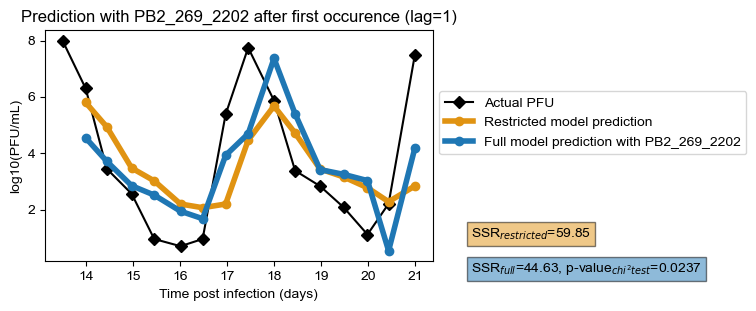

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
dpis = stationary_denovo_ts_df.index.values
actual_value = stationary_denovo_ts_df['plaque_assay']
ax.plot(dpis, actual_value, label='Actual PFU', marker='D', color='black')
ax.plot(dpis[1:], denovo_restr_pred, label='Restricted model prediction', marker='o', color='#e09312', linewidth=4)
ax.plot(dpis[1:], denovo_full_pred, label='Full model prediction with PB2_269_2202', marker='o', color='tab:blue', linewidth=4)
ax.set_title('Prediction with PB2_269_2202 after first occurence (lag=1)')
ax.set_xlabel('Time post infection (days)')
ax.set_ylabel('log10(PFU/mL)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.6))
ax.set_yscale('linear')
ax.text(1.1, 0, f'SSR$_{{full}}$={SSR_full:.2f}, p-value$_{{chi^2test}}$={denovo_gc_test_results[1][0]["ssr_chi2test"][1]:.4f}', 
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='square', facecolor='tab:blue', alpha=0.5))
ax.text(1.1, 0.15, f'SSR$_{{restricted}}$={SSR_restricted:.2f}', 
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='square', facecolor='#e09312', alpha=0.5))
plt.show()

# Granger causality test only on non-zero parts of the time series for PB2_129_2176

In [ ]:
gc_prediction_summary[1][gc_prediction_summary[1]['key'] == 'PB2_129_2176']

,key,granger_label,optimal_lag,diff_level,ssr_chi2test_pval,significant_pvals,mape,mae,rmse,nrsme,...,relative_wmape,relative_dtw,relative_mse,dtw_aligned_mape,ssr,weighted_ssr,pred_data,norm_ssr_chi2test_pval,group_norm_ssr_chi2test_pval,corrected_color
1710,PB2_129_2176,non-related,1,1.0,0.258198,0,0.736119,1.609192,1.96292,0.504412,...,0.979431,1.034353,0.970461,38.908454,161.828379,0.053999,"([0.5, 0.99, 1.4, 2.02, 2.49, 2.95, 3.46, 4.0,...",2.58198,0.258627,"(0.33070357554786617, 0.33070357554786617, 0.3..."


In [ ]:
ts_df['PB2_129_2176']

-0.02     32.0
 0.50     58.0
 0.99     61.0
 1.40     74.0
 2.02      NaN
 2.49      NaN
 2.95      NaN
 3.46     39.0
 4.00     65.0
 4.47     48.0
 5.00     35.0
 5.48     17.0
 5.99      NaN
 6.49      NaN
 6.96      NaN
 7.42      NaN
 7.95      3.0
 8.42      NaN
 8.96      0.0
 9.42      2.0
 9.97      NaN
 10.43     NaN
 10.96     NaN
 11.42     NaN
 11.97     NaN
 12.43     0.0
 12.97     8.0
 13.50     0.0
 13.99     NaN
 14.44     NaN
 14.97     NaN
 15.45     NaN
 16.01     0.0
 16.48     NaN
 16.97     0.0
 17.45     0.0
 18.00     0.0
 18.45     NaN
 18.98     NaN
 19.48     0.0
 19.99     0.0
 20.44     0.0
 21.00     0.0
Name: PB2_129_2176, dtype: float64

In [ ]:
# index at which the last value > 15 appears
last_non_zero_timepoint = ts_df['PB2_129_2176'].gt(15).iloc[::-1].idxmax()
print(f"Last time point with value > 15: {last_non_zero_timepoint}")

Last time point with value > 15: 5.48


In [ ]:
loss_ts_df = log_interpolated_ts_df[:last_non_zero_timepoint + 1][['plaque_assay', 'PB2_129_2176']].copy()
loss_ts_df

,plaque_assay,PB2_129_2176
-0.02,5.447160,1.518514
0.50,8.447158,1.770852
0.99,7.447158,1.792392
1.40,6.602060,1.875061
2.02,5.079185,1.821186
2.49,4.079217,1.759668
2.95,2.778874,1.687975
3.46,2.082785,1.602060
4.00,0.698970,1.819544
4.47,3.602169,1.690196


In [ ]:
stationary_loss_ts_df = make_stationary(loss_ts_df, max_diff=10, autolag='AIC', max_lag=None).df_stationary.fillna(0)
stationary_loss_ts_df

,plaque_assay,PB2_129_2176
-0.02,0.000000,0.000000
0.50,0.000000,0.252338
0.99,0.000000,0.021540
1.40,4.154900,0.082670
2.02,-0.832679,-0.053875
2.49,1.200685,-0.061518
2.95,-0.823283,-0.071693
3.46,0.904629,-0.085915
4.00,-1.291980,0.217484
4.47,4.974740,-0.129348


In [ ]:
loss_gc_test_results = grangercausalitytests(loss_ts_df[['plaque_assay', 'PB2_129_2176']], maxlag=1, verbose=True)
loss_gc_test_results_rv = grangercausalitytests(loss_ts_df[['PB2_129_2176', 'plaque_assay']], maxlag=1, verbose=True)
loss_full_pred = loss_gc_test_results[1][1][1].predict()
loss_restr_pred = loss_gc_test_results[1][1][0].predict()
SSR_full_loss = loss_gc_test_results[1][1][1].ssr
SSR_restricted_loss = loss_gc_test_results[1][1][0].ssr
print(f"Restricted model SSR: {SSR_restricted_loss:.2f}")
print(f"Full model SSR: {SSR_full_loss:.2f}")


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1177  , p=0.7394  , df_denom=9, df_num=1
ssr based chi2 test:   chi2=0.1569  , p=0.6920  , df=1
likelihood ratio test: chi2=0.1559  , p=0.6929  , df=1
parameter F test:         F=0.1177  , p=0.7394  , df_denom=9, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0540  , p=0.8214  , df_denom=9, df_num=1
ssr based chi2 test:   chi2=0.0720  , p=0.7884  , df=1
likelihood ratio test: chi2=0.0718  , p=0.7888  , df=1
parameter F test:         F=0.0540  , p=0.8214  , df_denom=9, df_num=1
Restricted model SSR: 43.55
Full model SSR: 42.99


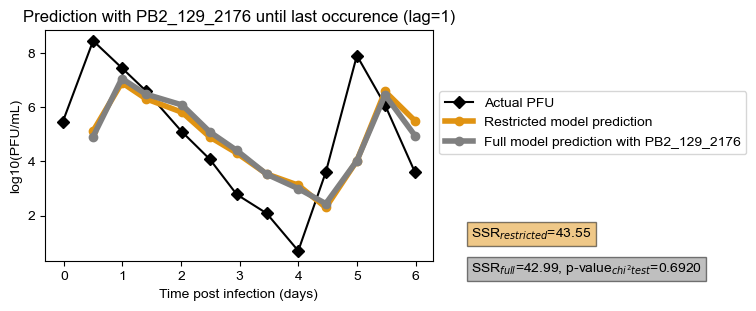

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3))
dpis = loss_ts_df.index.values
actual_value = loss_ts_df['plaque_assay']
ax.plot(dpis, actual_value, label='Actual PFU', marker='D', color='black')
ax.plot(dpis[1:], loss_restr_pred, label='Restricted model prediction', marker='o', color='#e09312', linewidth=4)
ax.plot(dpis[1:], loss_full_pred, label='Full model prediction with PB2_129_2176', marker='o', color='grey', linewidth=4)
ax.set_title('Prediction with PB2_129_2176 until last occurence (lag=1)')
ax.set_xlabel('Time post infection (days)')
ax.set_ylabel('log10(PFU/mL)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.6))
ax.set_yscale('linear')
ax.text(1.1, 0, f'SSR$_{{full}}$={SSR_full_loss:.2f}, p-value$_{{chi^2test}}$={loss_gc_test_results[1][0]["ssr_chi2test"][1]:.4f}', 
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='square', facecolor='grey', alpha=0.5))
ax.text(1.1, 0.15, f'SSR$_{{restricted}}$={SSR_restricted_loss:.2f}', 
        transform=ax.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='square', facecolor='#e09312', alpha=0.5))
plt.show()

In [70]:
pd.DataFrame(ref_ols_performance_dct).T.reset_index().rename(columns={'index': 'lag'}).to_csv(f'{output_prefix}/ref_ols_performance_dct.csv', index=False)

In [69]:
output_prefix

'data/outputs/plus1_log10_linear_imputation'

In [ ]:
ref_ols_performance_df = pd.DataFrame(ref_ols_performance_dct).T.reset_index().rename(columns={'index': 'lag'})
for lag in range(1, max_fixed_lag):
    gc_prediction_summary[lag].to_csv(f'{output_prefix}/gc_prediction_summary_lag{lag}.csv', index=False)
    gc_prediction_summary_corrected[lag].to_csv(f'{output_prefix}/gc_prediction_summary_corrected_lag{lag}.csv', index=False)